# Asistente conversacional sobre el Código Nacional de Tránsito con RAG

**Maestría en Inteligencia Artificial Aplicada — Universidad Icesi**<br>
**Procesamiento de Lenguaje Natural · Taller de la semana 5**

**Integrantes:** William Alberto Suaza Losada · Anderson Trujillo · Bairon Gutiérrez

## 1. El problema

Casi todos en Colombia hemos tenido alguna duda de tránsito: si el parrillero de la moto también debe usar casco, cuánto cuesta pasarse un semáforo en rojo o cada cuánto le toca la revisión técnico-mecánica a un carro. La respuesta está en la **Ley 769 de 2002, el Código Nacional de Tránsito Terrestre**, pero leerla no es sencillo. Tiene alrededor de 180 artículos, muchos de ellos modificados por leyes y decretos posteriores, y las multas no aparecen en pesos sino en salarios mínimos diarios (SMLDV), repartidas en literales como "C.29" dentro de un único artículo de más de dos mil palabras.

Un modelo de lenguaje por sí solo tampoco resuelve el problema. Puede contestar con mucha seguridad, citar un artículo que no existe o mezclar normas de otros países. Lo que queremos es un asistente que responda en lenguaje sencillo **y** diga en qué artículo se apoya, para que la persona pueda comprobarlo. Por eso planteamos un sistema de **generación aumentada por recuperación (RAG)**: primero se buscan los fragmentos de la ley más relacionados con la pregunta y después un modelo de lenguaje redacta la respuesta usando solo esos fragmentos.

Creemos que RAG encaja bien con este caso por tres razones:

1. **El corpus es cerrado y oficial.** No hace falta que el modelo "sepa" de tránsito; basta con que lea bien el texto que le entregamos.
2. **La ley ya viene organizada en artículos.** Esa estructura permite citar con precisión y verificar si la cita es correcta.
3. **Las normas cambian.** Con RAG, actualizar el asistente es volver a indexar el texto, sin reentrenar ningún modelo.

### Pregunta de investigación

> ¿Qué combinación de fragmentación, modelo de embeddings, número de fragmentos recuperados y re-ranking encuentra mejor los artículos correctos para preguntas coloquiales sobre el Código de Tránsito, y qué modelo generador aprovecha mejor ese contexto para responder con citas correctas y sin inventar?

### Hipótesis

1. **H1.** Fragmentar siguiendo la estructura de la ley (parágrafos, literales y definiciones) recuperará mejor que usar el artículo completo o una ventana fija de palabras, porque respeta las unidades con las que está escrita la norma.
2. **H2.** Los prefijos `query:` y `passage:` de los modelos E5 mejorarán la recuperación, porque así fueron entrenados.
3. **H3.** El re-ranking con un cross-encoder mejorará sobre todo el MRR, es decir, subirá el artículo correcto a las primeras posiciones.
4. **H4.** `gemma3:4b`, que tiene más parámetros, citará mejor que `llama3.2:3b`, a cambio de responder más despacio.
5. **H5.** Un umbral sobre el puntaje de relevancia permitirá rechazar preguntas que no trata el código sin perder muchas preguntas válidas.

---
## 2. Objetivos y alcance

**Objetivo general.** Construir y evaluar un chatbot RAG que responda preguntas ciudadanas sobre la Ley 769 de 2002 citando los artículos en los que se apoya.

**Objetivos específicos**

1. Descargar el texto consolidado de la ley desde el Gestor Normativo de Función Pública y limpiarlo hasta tener un registro por artículo con sus metadatos.
2. Explorar el corpus para decidir cómo fragmentarlo.
3. Construir un set de evaluación propio, con preguntas en lenguaje coloquial y su artículo correcto.
4. Comparar tres estrategias de fragmentación y cuatro variantes de embeddings, con y sin re-ranking y para distintos valores de k.
5. Comparar dos modelos generadores servidos localmente con Ollama.
6. Calibrar un umbral para que el asistente se abstenga cuando la pregunta no está en el código.
7. Integrar todo en un chatbot conversacional con Gradio que muestre las fuentes consultadas.

**Alcance.** Trabajamos solo con la Ley 769 de 2002 consolidada. Quedan por fuera las resoluciones del Ministerio de Transporte, los decretos reglamentarios y las normas locales (pico y placa, impuestos, tarifas). El asistente orienta, pero **no reemplaza una asesoría legal**.

---
## 3. Entorno y reproducibilidad

El cuaderno está pensado para Google Colab con una GPU T4. Primero detectamos si estamos en Colab; solo en ese caso instalamos las dependencias, con versiones fijas para que otra persona obtenga el mismo entorno. Fijamos las semillas de `random`, NumPy y PyTorch, y más adelante los modelos generadores trabajan con temperatura 0 y una semilla fija.

Los datos no se descargan de la página oficial en cada ejecución. Usamos una copia limpia (snapshot) guardada en nuestro repositorio, porque la ley se sigue reformando y la página podría cambiar o no responder. La descarga en vivo queda como respaldo y como forma de comprobar si el texto cambió.

In [1]:
import sys

IN_COLAB = 'google.colab' in sys.modules
print('Ejecutando en Colab:', IN_COLAB)

Ejecutando en Colab: True


In [2]:
if IN_COLAB:
    !pip install -q "langchain-classic==1.0.8" "langchain-community==0.4.2" "langchain-huggingface==1.2.2" "langchain-ollama==1.1.0" "faiss-cpu==1.15.1" "sentence-transformers==6.1.0" "ollama==0.6.2" "gradio==6.28.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 27.5 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 94.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 98.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 740.6/740.6 kB 54.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.4/31.4 MB 69.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 8.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [3]:
import gc
import hashlib
import io
import json
import os
import random
import re
import shutil
import socket
import ssl
import subprocess
import tempfile
import time
import unicodedata
import warnings
from collections import Counter
from datetime import date
from pathlib import Path
from typing import Any, Optional

import certifi
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import torch
from bs4 import BeautifulSoup
from matplotlib.ticker import PercentFormatter

warnings.filterwarnings('ignore')
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
pd.set_option('display.max_colwidth', 120)
plt.rcParams['figure.dpi'] = 110

print('Dispositivo:', DEVICE, f'({torch.cuda.get_device_name(0)})' if DEVICE == 'cuda' else '')
print('PyTorch:', torch.__version__)

Dispositivo: cuda (Tesla T4)
PyTorch: 2.11.0+cu128


---
## 4. Obtención y limpieza del corpus

Tomamos el texto de la ley del **Gestor Normativo de Función Pública**, que publica la versión consolidada en una sola página e integra las reformas posteriores. Al revisar el HTML vimos que, además del texto vigente, la página trae mucho material que no queremos que el asistente lea como si fuera ley:

- versiones anteriores de cada artículo ocultas tras un botón "Norma Anterior", y bloques "Texto anterior" / "Texto original" que repiten redacciones derogadas (el artículo 131 de multas aparece dos veces por esto);
- notas de vigencia como "Modificado por el art. 21, Ley 1383 de 2010";
- notas de jurisprudencia ("Texto subrayado declarado INEXEQUIBLE por la Corte Constitucional…") y remisiones del tipo "Ver Resolución…".

Las reglas de limpieza que aplicamos son:

1. Eliminar los bloques ocultos y todo lo que viene después de "Texto anterior" o "Texto original" hasta el siguiente artículo.
2. Quitar las notas de vigencia, jurisprudencia y remisiones, pero guardar las leyes y decretos que modificaron cada artículo en el campo `modificado_por`.
3. Cuando una nota dice que el texto **subrayado** fue declarado INEXEQUIBLE, retirar ese texto subrayado, porque ya no tiene efecto.
4. Marcar como no vigentes los artículos declarados inexequibles o derogados en su totalidad, y los que quedan vacíos después de limpiar. No entran al índice, pero los contamos en el análisis exploratorio.
5. Reconocer títulos y capítulos (incluidos los que vienen con letras espaciadas, como "T I T U L O I I") para guardar la ubicación de cada artículo.

El orden de carga es: archivo local en `../data`, luego el snapshot del repositorio en GitHub y, solo si ambos fallan, la descarga y limpieza en vivo con las mismas funciones.

In [4]:
FUENTE_URL = 'https://www.funcionpublica.gov.co/eva/gestornormativo/norma.php?i=5557'
# El servidor no envía el certificado intermedio; se añade el oficial de Sectigo sin desactivar la verificación.
INTERMEDIO_URL = 'http://crt.sectigo.com/SectigoRSAOrganizationValidationSecureServerCA.crt'

RE_TITULO = re.compile(r'^T\s*[IÍ]\s*T\s*U\s*L\s*O\s+([IVXL](?:\s*[IVXL])*)\s*\.?$')
RE_CAPITULO = re.compile(r'^CAP[IÍ]TULO\s+([IVXL]+)\s*\.?\s*(.*)$')
RE_ARTICULO = re.compile(r'^A\s?RT[IÍ]CULO\s+(\d+)\s*(?:([A-Z])\b|-\s*(\d+))?\s*[°ºo]?\s*\.?\s*(.*)$')
RE_TRANSITORIO = re.compile(r'^A\s?RT[IÍ]CULO\s+TRANSITOR[IÍ]O\s*\.?\s*(.*)$')
RE_FIN = re.compile(r'^El Presidente del honorable Senado')
RE_OMITIR_DESDE = re.compile(r'^(Texto anterior|Texto original)')
RE_PARRAFO_NOTA = re.compile(
    r'^\(?\s*(Ver\s|Sentencia\s|NOTA:|Declarado\s|Texto subrayado|Norma Anterior|Jurisprudencia)')
RE_NOTA_PARENTESIS = re.compile(
    r'\((?=[^()]*(?:[Mm]odificad|MODIFICAD|[Aa]dicionad|ADICIONAD|[Ss]ustituid|[Dd]erogad|[Rr]eglamentad|\bMod\b|Ver\s))[^()]*\)')
RE_NOTA_HASTA_FIN = re.compile(
    r'(?:Texto subrayado|Parágrafo declarado|Inciso declarado|Declarado\s|NOTA:|La expresión subrayada).*$')
RE_NOTA_CAMBIO = re.compile(
    r'(?i)\b(?:modificad[oa]s?(?:\s+parcialmente)?|adicionad[oa]s?|sustituid[oa]|derogad[oa]|eliminad[oa]|reglamentad[oa])'
    r'\s+por\b.{0,90}?\b(?:ley|decreto|resoluci[oó]n)\b.{0,45}?\d+\s+de\s+\d{4}'
    r'(?:\s+Congreso de la República)?\.?(?:\s*El nuevo texto es el siguiente:)?')
RE_NOTA_CORCHETES = re.compile(r'Modificado\s*\[?\s*Artículo\s+\d+\s+LEY\s+\d+\s+de\s+\d{4}\s*\]?')
RE_NOTA_VER = re.compile(
    r'\bVer\s+(?:Resoluci[oó]n|Concepto|Fallo|Sentencia|Ley|Decreto|los\s+arts?\.?|arts?\.).*?\bde\s+\d{4}\b\)?')
RE_NUEVO_TEXTO = re.compile(r'(?:El nuevo texto es el siguiente:|^INEXEQUIBLE\.)\s*')
RE_LITERAL_ELIMINADO = re.compile(r'^[A-Z]\.\d+\.?\s+Eliminad[oa]\b')
RE_LITERAL_VACIO = re.compile(r'^[A-Z](?:\.\d+)?\.?$')
RE_REFORMA = re.compile(
    r'(?i)(?:modificad|adicionad|sustituid|derogad|eliminad)[oa]s?\b.{0,90}?\b(ley|decreto)(?:\s+nacional|\s+ley)?\s+0*(\d+)\s+de\s+(\d{4})')
RE_SUBRAYADO_INEXEQUIBLE = re.compile(
    r'(?i)subrayad[oa]s?\s+(?:que\s+se\s+declaró|declarad[oa]s?|fue\s+declarad[oa])\s+INEXEQUIBLE')


def descargar_html(url=FUENTE_URL, timeout=120):
    der = requests.get(INTERMEDIO_URL, timeout=timeout).content
    ruta_bundle = Path(tempfile.gettempdir()) / 'bundle_funcionpublica.pem'
    ruta_bundle.write_text(Path(certifi.where()).read_text() + '\n' + ssl.DER_cert_to_PEM_cert(der))
    r = requests.get(url, timeout=timeout, verify=str(ruta_bundle), headers={'User-Agent': 'Mozilla/5.0'})
    r.raise_for_status()
    # La página declara ISO-8859-1 pero el contenido real es UTF-8.
    return r.content.decode('utf-8-sig')


def normalizar(texto):
    return ' '.join(texto.replace('\xa0', ' ').split())


def limpiar_parrafo(texto):
    if RE_PARRAFO_NOTA.match(texto):
        return ''
    texto = RE_NOTA_PARENTESIS.sub('', texto)
    texto = RE_NOTA_CORCHETES.sub('', texto)
    texto = RE_NOTA_HASTA_FIN.sub('', texto)
    texto = RE_NOTA_CAMBIO.sub('', texto)
    texto = RE_NOTA_VER.sub('', texto)
    texto = re.sub(r'\s+([,.;:])', r'\1', texto)
    texto = re.sub(r'^[\s,.;:]+', '', texto)
    texto = RE_NUEVO_TEXTO.sub('', texto)
    if '?' not in texto:
        texto = texto.replace('¿', '')
    texto = re.sub(r'([.;:,])(?:\s*[.,])+', r'\1', texto)
    return normalizar(texto)


def extraer_nombre(texto):
    m = re.match(r'^(.+?)\.(?:\s|$)', texto)
    if not m:
        return '', texto
    candidato = m.group(1)
    letras = [c for c in candidato if c.isalpha()]
    mayusculas = sum(c.isupper() for c in letras) / max(len(letras), 1)
    palabras = len(candidato.split())
    if mayusculas > 0.7 or palabras <= 8 or (palabras <= 16 and ',' not in candidato):
        return candidato.strip(), texto[m.end():].strip()
    return '', texto


def parsear_ley(html, fuente_url=FUENTE_URL):
    sopa = BeautifulSoup(html, 'html.parser')
    contenido = sopa.select_one('div.descripcion-contenido')
    for boton in contenido.find_all('button'):
        boton.decompose()
    for oculto in contenido.select('div[id^=juris]'):
        oculto.decompose()

    articulos, actual = [], None
    titulo = titulo_nombre = capitulo = capitulo_nombre = ''
    esperando = None
    omitiendo = False
    for bloque in contenido.find_all(['p', 'h1', 'h2', 'h3', 'h4', 'h5', 'h6']):
        texto = normalizar(bloque.get_text(' '))
        if not texto:
            continue
        if RE_FIN.match(texto):
            break
        m_tit, m_cap = RE_TITULO.match(texto), RE_CAPITULO.match(texto)
        m_art, m_tra = RE_ARTICULO.match(texto), RE_TRANSITORIO.match(texto)
        if m_tit:
            titulo, titulo_nombre, capitulo, capitulo_nombre = m_tit.group(1).replace(' ', ''), '', '', ''
            actual, esperando, omitiendo = None, 'titulo', False
            continue
        if m_cap:
            capitulo, capitulo_nombre = m_cap.group(1), limpiar_parrafo(m_cap.group(2)).rstrip('.')
            actual, esperando, omitiendo = None, None if capitulo_nombre else 'capitulo', False
            continue
        if m_art or m_tra:
            if m_art:
                numero = m_art.group(1) + (m_art.group(2) or '') + (f'-{m_art.group(3)}' if m_art.group(3) else '')
            else:
                numero = 'Transitorio'
            actual = {'articulo': numero, 'titulo': titulo, 'titulo_nombre': titulo_nombre,
                      'capitulo': capitulo, 'capitulo_nombre': capitulo_nombre, 'bloques': [bloque]}
            articulos.append(actual)
            esperando, omitiendo = None, False
            continue
        if esperando == 'titulo':
            titulo_nombre = limpiar_parrafo(texto).rstrip('.')
            esperando = None
            continue
        if esperando == 'capitulo':
            capitulo_nombre = limpiar_parrafo(texto).rstrip('.')
            esperando = None
            continue
        if actual is None or omitiendo:
            continue
        if RE_OMITIR_DESDE.match(texto):
            omitiendo = True
            continue
        actual['bloques'].append(bloque)

    registros = []
    for orden, art in enumerate(articulos):
        crudo = '\n'.join(normalizar(b.get_text(' ')) for b in art['bloques'])
        if RE_SUBRAYADO_INEXEQUIBLE.search(crudo):
            for bloque in art['bloques']:
                for subrayado in bloque.find_all('u'):
                    subrayado.decompose()
        parrafos = [normalizar(b.get_text(' ')) for b in art['bloques']]
        encabezado = RE_ARTICULO.match(parrafos[0]) or RE_TRANSITORIO.match(parrafos[0])
        resto = limpiar_parrafo(encabezado.groups()[-1])
        # Literales eliminados por reformas posteriores (p. ej. E.3 del art. 131).
        cuerpo = [limpiar_parrafo(p) for p in parrafos[1:] if not RE_LITERAL_ELIMINADO.match(p)]
        cuerpo = [p for p in cuerpo if p and not RE_LITERAL_VACIO.match(p)]
        if resto:
            nombre, resto = extraer_nombre(resto)
        elif cuerpo:
            nombre, primero = extraer_nombre(cuerpo[0])
            cuerpo = ([primero] if primero else []) + cuerpo[1:]
        else:
            nombre = ''
        texto = '\n'.join(([resto] if resto else []) + cuerpo)
        reformas = sorted({f'{t.capitalize()} {int(n)} de {a}' for t, n, a in RE_REFORMA.findall(crudo)
                           if not (n.lstrip('0') == '769' and a == '2002')},
                          key=lambda s: (int(s.split()[-1]), s))
        encabezado_crudo = parrafos[0][:200]
        vigente = bool(texto) and not (
            re.search(r'INEXEQUIBLE\.', encabezado_crudo) and 'subrayad' not in encabezado_crudo
        ) and 'Este artículo fue derogado' not in crudo
        registros.append({
            'orden': orden, 'articulo': art['articulo'], 'nombre': nombre.rstrip('.').strip(),
            'titulo': art['titulo'], 'titulo_nombre': art['titulo_nombre'],
            'capitulo': art['capitulo'], 'capitulo_nombre': art['capitulo_nombre'],
            'texto': texto, 'modificado_por': reformas, 'vigente': vigente, 'fuente_url': fuente_url,
        })
    return registros

In [5]:
RUTA_LOCAL = Path('../data')
URL_REPO = 'https://raw.githubusercontent.com/777wills/miaa-nlp/main/data'
ARCHIVO_LEY = 'ley_769_2002_articulos.jsonl'
ARCHIVO_PREGUNTAS = 'preguntas_evaluacion_transito.csv'


def leer_recurso(nombre):
    ruta = RUTA_LOCAL / nombre
    if ruta.exists():
        return ruta.read_bytes(), f'archivo local {ruta}'
    try:
        r = requests.get(f'{URL_REPO}/{nombre}', timeout=60)
        r.raise_for_status()
        return r.content, 'snapshot del repositorio en GitHub'
    except requests.RequestException as error:
        print(f'No se pudo leer {nombre} del repositorio: {error}')
        return None, None


contenido_ley, origen_ley = leer_recurso(ARCHIVO_LEY)
if contenido_ley is None:
    registros = parsear_ley(descargar_html())
    for registro in registros:
        registro['fecha_descarga'] = date.today().isoformat()
    contenido_ley = '\n'.join(json.dumps(r, ensure_ascii=False) for r in registros).encode('utf-8')
    origen_ley = 'descarga en vivo desde Función Pública'
else:
    registros = [json.loads(linea) for linea in contenido_ley.decode('utf-8').splitlines() if linea.strip()]

ley = pd.DataFrame(registros)
print('Origen:', origen_ley)
print('SHA-256:', hashlib.sha256(contenido_ley).hexdigest())
print('Fecha de descarga del texto:', ley['fecha_descarga'].iloc[0])
print(f'Artículos: {len(ley)} | vigentes: {ley.vigente.sum()} | no vigentes: {(~ley.vigente).sum()}')
ley[['articulo', 'nombre', 'titulo', 'capitulo', 'modificado_por', 'vigente']].head(8)

Origen: snapshot del repositorio en GitHub
SHA-256: a95835966bb71ad8d5467898b89065d7694abb3e93f18d07fc7dfaed5039cd9a
Fecha de descarga del texto: 2026-09-26
Artículos: 180 | vigentes: 176 | no vigentes: 4


,articulo,nombre,titulo,capitulo,modificado_por,vigente
0,1,ÁMBITO DE APLICACIÓN Y PRINCIPIOS,I,I,[Ley 1383 de 2010],True
1,2,DEFINICIONES,I,I,[],True
2,3,AUTORIDADES DE TRÁNSITO,I,II,[Ley 1383 de 2010],True
3,4,ACREDITACIÓN DE FORMACIÓN-PROGRAMAS DE SEGURIDAD,I,II,[Ley 1310 de 2009],True
4,5,DEMARCACIÓN Y SEÑALIZACIÓN VIAL,I,II,[Ley 1383 de 2010],True
5,6,ORGANISMOS DE TRÁNSITO,I,II,[],True
6,7,CUMPLIMIENTO RÉGIMEN NORMATIVO,I,II,[Ley 2197 de 2022],True
7,8,"REGISTRO UNICO NACIONAL DE TRÁNSITO, RUNT",I,III,[],True


Para ver qué tanto cambia el texto con la limpieza, descargamos la página en vivo y comparamos el artículo 131 (multas) tal como viene en el HTML, incluidas las versiones ocultas, con su versión limpia. También verificamos si la página cambió desde que tomamos el snapshot. Si la página no responde, la celda lo informa y el resto del cuaderno sigue funcionando con el snapshot.

In [6]:
try:
    html_vivo = descargar_html()
except requests.RequestException as error:
    html_vivo = None
    print('La página oficial no respondió; seguimos con el snapshot.', error)

if html_vivo is not None:
    contenido_vivo = BeautifulSoup(html_vivo, 'html.parser').select_one('div.descripcion-contenido')
    texto_crudo = normalizar(contenido_vivo.get_text(' '))
    inicio, fin = texto_crudo.find('ARTÍCULO 131.'), texto_crudo.find('ARTÍCULO 132.')
    crudo_131 = texto_crudo[inicio:fin]
    limpio_131 = ley.loc[ley.articulo == '131', 'texto'].iloc[0]

    print(f'Página completa: {len(texto_crudo.split()):,} palabras en crudo '
          f'frente a {ley.texto.str.split().str.len().sum():,} después de limpiar')
    print(f'Artículo 131: {len(crudo_131.split()):,} palabras en crudo frente a {len(limpio_131.split()):,} limpio')
    texto_limpio = '\n'.join(ley.texto)
    for marca in ['Norma Anterior', 'Texto anterior', 'Modificado por', 'EXEQUIBLE', 'Ver Resolución']:
        print(f'  "{marca}": {texto_crudo.count(marca)} veces en la página, {texto_limpio.count(marca)} en el corpus limpio')
    print('\nInicio en crudo:\n', crudo_131[:500])
    print('\nInicio limpio:\n', limpio_131[:500])

    vivo = pd.DataFrame(parsear_ley(html_vivo))
    comparacion = ley[['orden', 'articulo', 'texto']].merge(vivo[['orden', 'articulo', 'texto']], on=['orden', 'articulo'],
                                                             how='outer', suffixes=('_snapshot', '_vivo'), indicator=True)
    cambiados = comparacion[(comparacion['_merge'] != 'both') |
                            (comparacion['texto_snapshot'] != comparacion['texto_vivo'])]
    print(f'\nArtículos que cambiaron desde el snapshot: {len(cambiados)}')

Página completa: 36,645 palabras en crudo frente a 28,501 después de limpiar
Artículo 131: 4,359 palabras en crudo frente a 2,104 limpio
  "Norma Anterior": 12 veces en la página, 0 en el corpus limpio
  "Texto anterior": 2 veces en la página, 0 en el corpus limpio
  "Modificado por": 75 veces en la página, 0 en el corpus limpio
  "EXEQUIBLE": 31 veces en la página, 0 en el corpus limpio
  "Ver Resolución": 21 veces en la página, 0 en el corpus limpio

Inicio en crudo:
 ARTÍCULO 131. MULTAS. Modificado por el art. 21, Ley 1383 de 2010 . El nuevo texto es el siguiente: Los infractores de las normas de tránsito serán sancionados con la imposición de multas, de acuerdo con el tipo de infracción así: A. Será sancionado con multa equivalente a cuatro (4) salarios mínimos legales diarios vigentes (SMLDV) el conductor de un vehículo no automotor o de tracción animal que incurra en cualquiera de las siguientes infracciones: A.1. No transitar por la derecha de la vía. A

Inicio limpio:
 Los inf

**Lo que observamos.** Después de limpiar, el corpus queda en 28.501 palabras; la página en crudo tiene 36.645. En el artículo 131 la diferencia es mayor, de 4.359 a 2.104 palabras, porque la página repite la redacción anterior del artículo completo. En el texto limpio no queda ninguna de las marcas que buscamos ("Norma Anterior", "Texto anterior", "Modificado por", "EXEQUIBLE", "Ver Resolución"). Al procesar la página en vivo con las mismas funciones obtuvimos los mismos artículos que en el snapshot, sin ningún cambio.

---
## 5. Análisis exploratorio del corpus

Antes de decidir cómo partir el texto queremos saber cómo está repartido. Nos interesan tres cosas: cómo se distribuyen los artículos entre los títulos del código, qué tan largos son (eso define el tamaño de los fragmentos) y qué tanto ha sido reformada la ley.

Artículos excluidos del índice:


,articulo,nombre,palabras,modificado_por
95,93-1,,0,[Ley 1383 de 2010]
131,128,Mecanismo de subasta de vehículos abandonados,131,[Ley 1730 de 2014]
174,167,VEHÍCULOS INMOVILIZADOS POR ORDEN JUDICIAL,39,[Ley 1955 de 2019]
178,Transitorio,,0,[]


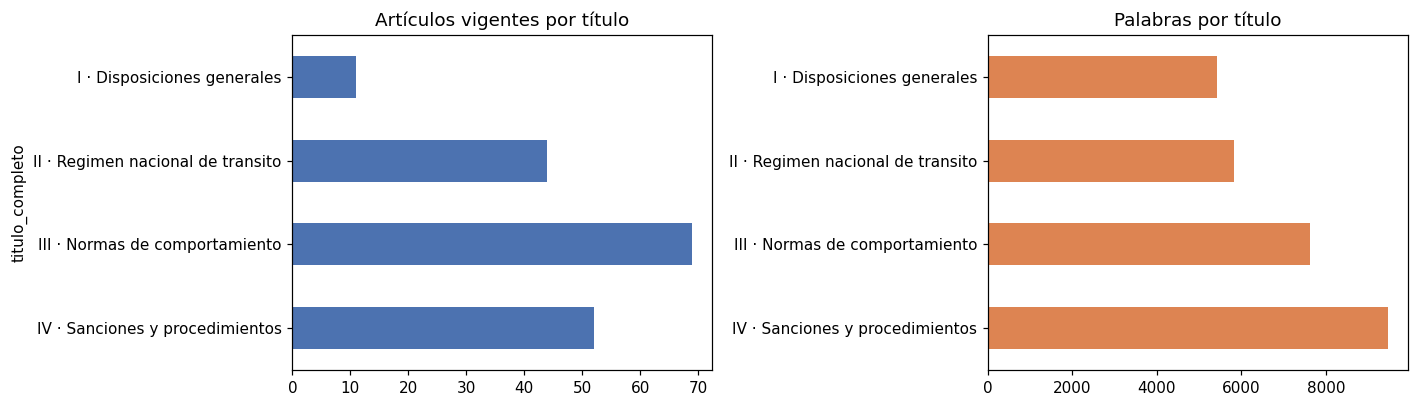

In [7]:
ley['palabras'] = ley['texto'].str.split().str.len()
vigentes = ley[ley.vigente].reset_index(drop=True)

print('Artículos excluidos del índice:')
display(ley.loc[~ley.vigente, ['articulo', 'nombre', 'palabras', 'modificado_por']])

por_titulo = (vigentes.assign(titulo_completo=vigentes.titulo + ' · ' + vigentes.titulo_nombre.str.capitalize())
              .groupby('titulo_completo', sort=False)
              .agg(articulos=('articulo', 'count'), palabras=('palabras', 'sum')))

fig, ejes = plt.subplots(1, 2, figsize=(13, 3.8))
por_titulo['articulos'].plot.barh(ax=ejes[0], color='#4C72B0')
ejes[0].set_title('Artículos vigentes por título')
ejes[0].invert_yaxis()
por_titulo['palabras'].plot.barh(ax=ejes[1], color='#DD8452')
ejes[1].set_title('Palabras por título')
ejes[1].invert_yaxis()
ejes[1].set_ylabel('')
plt.tight_layout()
plt.show()

### Longitud de los artículos

Esta es la variable que más nos importa para fragmentar. Si la mayoría de artículos son cortos, un artículo puede ser un fragmento natural; si hay artículos muy largos, un solo vector tendría que resumir muchos temas a la vez.

count     176.0
mean      161.0
std       301.8
min        11.0
25%        43.8
50%        94.5
75%       184.8
max      3171.0

Percentiles:
 0.10      34.0
0.25      44.0
0.50      94.0
0.75     185.0
0.90     294.0
0.95     372.0
0.99    1182.0


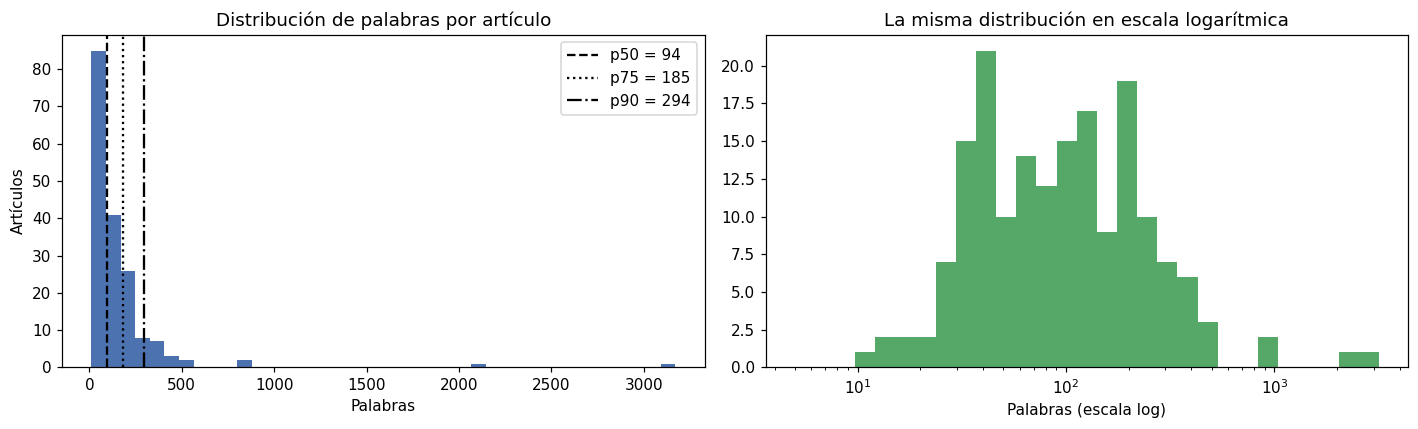

Artículos más largos:


,articulo,nombre,palabras
1,2,DEFINICIONES,3171
132,131,MULTAS,2104
124,122,TIPOS DE SANCIONES,875
137,136,REDUCCIÓN DE LA SANCIÓN,866
6,7,CUMPLIMIENTO RÉGIMEN NORMATIVO,532
127,125,INMOVILIZACIÓN,522
18,19,REQUISITOS,439
53,53,CENTROS DE DIAGNÓSTICO AUTOMOTOR,427


In [8]:
percentiles = vigentes['palabras'].quantile([0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]).round(0)
print(vigentes['palabras'].describe().round(1).to_string())
print('\nPercentiles:\n', percentiles.to_string())

fig, ejes = plt.subplots(1, 2, figsize=(13, 4))
ejes[0].hist(vigentes['palabras'], bins=40, color='#4C72B0')
for q, estilo in [(0.50, '--'), (0.75, ':'), (0.90, '-.')]:
    valor = vigentes['palabras'].quantile(q)
    ejes[0].axvline(valor, color='black', linestyle=estilo, label=f'p{int(q * 100)} = {valor:.0f}')
ejes[0].set_title('Distribución de palabras por artículo')
ejes[0].set_xlabel('Palabras')
ejes[0].set_ylabel('Artículos')
ejes[0].legend()
ejes[1].hist(vigentes['palabras'], bins=np.logspace(np.log10(5), np.log10(vigentes['palabras'].max()), 30), color='#55A868')
ejes[1].set_xscale('log')
ejes[1].set_title('La misma distribución en escala logarítmica')
ejes[1].set_xlabel('Palabras (escala log)')
plt.tight_layout()
plt.show()

print('Artículos más largos:')
vigentes.nlargest(8, 'palabras')[['articulo', 'nombre', 'palabras']]

### Reformas de la ley

El campo `modificado_por` guarda las leyes y decretos que tocaron cada artículo. Nos sirve para entender por qué el texto es difícil de seguir para un ciudadano, y para identificar los temas que más se han reformado.

Artículos vigentes con al menos una reforma: 59 de 176
Normas distintas que modificaron el código: 25


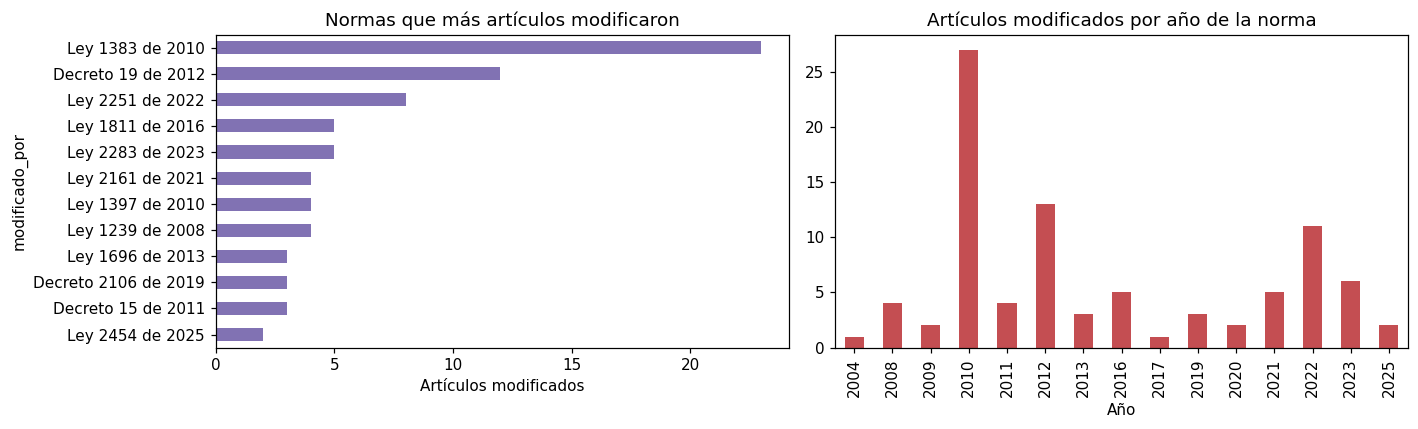

,articulo,nombre,reformas
18,19,REQUISITOS,5
53,53,CENTROS DE DIAGNÓSTICO AUTOMOTOR,4
137,136,REDUCCIÓN DE LA SANCIÓN,4
52,52,PRIMERA REVISIÓN DE LOS VEHÍCULOS AUTOMOTORES,3
108,106,LÍMITES DE VELOCIDAD EN VÍAS URBANAS Y CARRETERAS MUNICIPALES,3
109,107,LÍMITES DE VELOCIDAD EN CARRETERAS NACIONALES Y DEPARTAMENTALES,3


In [9]:
reformas = vigentes[['articulo', 'modificado_por']].explode('modificado_por').dropna()
reformas['anio'] = reformas['modificado_por'].str.extract(r'(\d{4})$').astype(int)

print(f'Artículos vigentes con al menos una reforma: {(vigentes.modificado_por.apply(len) > 0).sum()} '
      f'de {len(vigentes)}')
print(f'Normas distintas que modificaron el código: {reformas.modificado_por.nunique()}')

fig, ejes = plt.subplots(1, 2, figsize=(13, 4))
reformas['modificado_por'].value_counts().head(12).sort_values().plot.barh(ax=ejes[0], color='#8172B3')
ejes[0].set_title('Normas que más artículos modificaron')
ejes[0].set_xlabel('Artículos modificados')
reformas.groupby('anio').size().plot.bar(ax=ejes[1], color='#C44E52')
ejes[1].set_title('Artículos modificados por año de la norma')
ejes[1].set_xlabel('Año')
plt.tight_layout()
plt.show()

vigentes.assign(reformas=vigentes.modificado_por.apply(len)).nlargest(6, 'reformas')[['articulo', 'nombre', 'reformas']]

### Lo que observamos en el corpus

- **Distribución por títulos.** El título III (normas de comportamiento) tiene más artículos, 69, pero el título IV (sanciones y procedimientos) tiene más texto, cerca de 9.400 palabras, porque ahí están los artículos 131 (multas), 122 (tipos de sanciones) y 136 (reducción de la sanción). El título I solo tiene 11 artículos y aun así suma unas 5.400 palabras; más de la mitad son del artículo 2, el de las definiciones.
- **Longitud.** La distribución está muy sesgada. La mediana es de 94 palabras, el 75 % de los artículos tiene hasta 185 y el 90 % hasta 294, pero el artículo 2 llega a 3.171 palabras y el 131 a 2.104. En la escala logarítmica se ve que casi todo el corpus está entre 25 y 500 palabras, con unos pocos artículos muy separados del resto.
- **Reformas.** 59 de los 176 artículos vigentes tienen al menos una reforma, hecha por alguna de 25 normas distintas. La que más artículos modificó es la Ley 1383 de 2010 (23), seguida del Decreto 19 de 2012 (12) y la Ley 2251 de 2022 (8). Hay reformas de 2023 y 2025, así que el texto sigue cambiando. Los artículos más reformados son el 19 (requisitos de la licencia), con 5 reformas, y el 53 y el 136, con 4 cada uno.

Para fragmentar, esto quiere decir que un tamaño único no le sirve a todo el corpus. La mayoría de los artículos cabe completa en un fragmento pequeño, pero los pocos artículos enormes son justamente los de multas y definiciones, dos temas por los que la gente pregunta mucho.

---
## 6. Fragmentación

Comparamos tres formas de partir los 176 artículos vigentes:

- **(a) Artículo completo.** Cada artículo es un fragmento. Es la opción más simple, pero un artículo como el 131 (multas) o el 2 (definiciones) queda en un solo vector que mezcla decenas de temas. Además, los modelos E5 solo leen 512 tokens, así que el resto del artículo ni siquiera entra al embedding.
- **(b) Ventana deslizante de palabras.** Fragmentos de tamaño fijo con solapamiento. Elegimos **100 palabras con paso de 50** porque la mediana de los artículos está alrededor de 94 palabras: así la mitad de los artículos cabe completa en una ventana, y el solapamiento del 50 % evita que una idea quede partida justo en el borde.
- **(c) Estructural.** Los artículos de hasta 150 palabras (cerca del 70 % del corpus) se dejan enteros. Los más largos se parten por su propia estructura: cada parágrafo inicia un fragmento nuevo, y cuando un párrafo termina en dos puntos (por ejemplo, "Será sancionado con multa equivalente a quince (15) SMLDV… las siguientes infracciones:") lo repetimos al inicio de cada fragmento de la lista que sigue. Así un fragmento con el literal C.2 lleva también el valor de la multa. Los elementos de una lista se agrupan hasta llegar a 150 palabras.

Para que la comparación sea justa, las tres estrategias anteponen el mismo encabezado a cada fragmento (número y nombre del artículo, título y capítulo). Ese encabezado también le sirve al modelo generador para saber qué artículo está leyendo y citarlo.

In [10]:
from langchain_core.documents import Document

TAM_VENTANA, PASO_VENTANA = 100, 50
MAX_PALABRAS_ESTRUCTURAL = 150
RE_PARAGRAFO = re.compile(r'^P[AÁ]R[AÁ]GRAFO', re.IGNORECASE)


def contar_palabras(texto):
    return len(texto.split())


def encabezado(fila):
    ubicacion = ' · '.join(x for x in [f'Título {fila.titulo} {fila.titulo_nombre.capitalize()}'.strip(),
                                       f'Capítulo {fila.capitulo} {fila.capitulo_nombre.capitalize()}'.strip()
                                       if fila.capitulo else ''] if x)
    nombre = f' – {fila.nombre}' if fila.nombre else ''
    return f'Artículo {fila.articulo}{nombre} (Ley 769 de 2002; {ubicacion})'


def documento(fila, texto, numero):
    return Document(page_content=f'{encabezado(fila)}\n{texto}',
                    metadata={'articulo': fila.articulo, 'nombre': fila.nombre, 'titulo': fila.titulo,
                              'capitulo': fila.capitulo, 'fragmento': numero})


def fragmentar_articulo(fila):
    return [documento(fila, fila.texto, 0)]


def fragmentar_ventana(fila, tam=TAM_VENTANA, paso=PASO_VENTANA):
    palabras = fila.texto.split()
    inicios = range(0, max(len(palabras) - tam + paso, 1), paso)
    return [documento(fila, ' '.join(palabras[i:i + tam]), n) for n, i in enumerate(inicios)]


def fragmentar_estructural(fila, max_palabras=MAX_PALABRAS_ESTRUCTURAL):
    if fila.palabras <= max_palabras:
        return [documento(fila, fila.texto, 0)]
    fragmentos, actual, introduccion = [], [], ''

    def cerrar():
        if actual:
            fragmentos.append('\n'.join(([introduccion] if introduccion else []) + actual))
            actual.clear()

    for parrafo in fila.texto.split('\n'):
        if RE_PARAGRAFO.match(parrafo):
            cerrar()
            introduccion = ''
        elif parrafo.endswith(':'):
            cerrar()
            introduccion = parrafo
            continue
        elif actual and sum(map(contar_palabras, actual)) + contar_palabras(parrafo) > max_palabras:
            cerrar()
        actual.append(parrafo)
    cerrar()
    if not fragmentos and introduccion:
        fragmentos.append(introduccion)
    return [documento(fila, texto, n) for n, texto in enumerate(fragmentos)]


ESTRATEGIAS = {'articulo': fragmentar_articulo, 'ventana': fragmentar_ventana, 'estructural': fragmentar_estructural}
FRAGMENTOS = {nombre: [doc for fila in vigentes.itertuples() for doc in funcion(fila)]
              for nombre, funcion in ESTRATEGIAS.items()}

resumen_fragmentos = pd.DataFrame({
    nombre: pd.Series([contar_palabras(d.page_content) for d in docs]).describe()[['count', 'mean', '50%', 'max']]
    for nombre, docs in FRAGMENTOS.items()}).T.round(1)
resumen_fragmentos.columns = ['fragmentos', 'palabras media', 'palabras mediana', 'palabras máx.']
resumen_fragmentos

,fragmentos,palabras media,palabras mediana,palabras máx.
articulo,176.0,183.8,119.0,3187.0
ventana,524.0,109.3,119.0,143.0
estructural,354.0,104.5,96.5,205.0


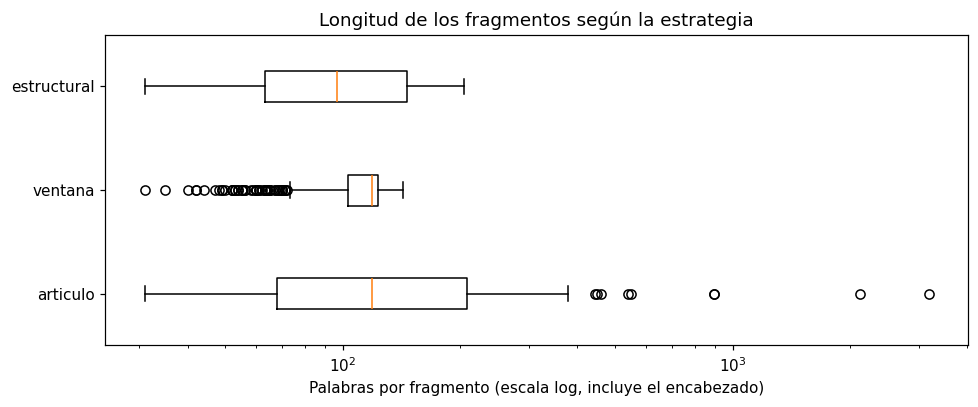

El artículo 131 queda en 15 fragmentos estructurales. Uno de ellos:

Artículo 131 – MULTAS (Ley 769 de 2002; Título IV Sanciones y procedimientos · Capítulo II Sanciones por incumplimiento de las normas de tránsito)
C. Será sancionado con multa equivalente a quince (15) salarios mínimos legales diarios vigentes (SMLDV) el conductor y/o propietario de un vehículo automotor que incurra en cualquiera de las siguientes infracciones:
C.1. Presentar licencia de conducción adulterada o ajena, lo cual dará lugar a la inmovilización del vehículo.
C.2. Estacionar un vehículo en sitios prohibidos.
C.3. Bloquear una calzada o intersección con un vehículo, salvo cuando el bloqueo obedezca a la ocurrencia de un accidente de tránsito.
C.4 Estacionar un vehículo sin tomar las debidas precauciones o sin colocar a la distancia señalada por este código, las señales de peligro reglamentarias.
C.5. No reducir la velocidad según lo indicado por este código, cuando transite por


In [11]:
fig, eje = plt.subplots(figsize=(9, 3.8))
eje.boxplot([[contar_palabras(d.page_content) for d in docs] for docs in FRAGMENTOS.values()], vert=False)
eje.set_yticks(range(1, len(FRAGMENTOS) + 1), list(FRAGMENTOS))
eje.set_xscale('log')
eje.set_xlabel('Palabras por fragmento (escala log, incluye el encabezado)')
eje.set_title('Longitud de los fragmentos según la estrategia')
plt.tight_layout()
plt.show()

ejemplo = [d for d in FRAGMENTOS['estructural'] if d.metadata['articulo'] == '131']
print(f'El artículo 131 queda en {len(ejemplo)} fragmentos estructurales. Uno de ellos:\n')
print(next(d.page_content for d in ejemplo if 'C.2.' in d.page_content)[:900])

**Lo que observamos.** Las tres estrategias producen fragmentos muy distintos:

- **Artículo completo:** 176 fragmentos, con una mediana de 119 palabras y un máximo de 3.187.
- **Ventana:** 524 fragmentos, casi todos de 100 a 143 palabras con el encabezado. Los puntos a la izquierda del diagrama son artículos cortos que caben en una sola ventana más pequeña.
- **Estructural:** queda en el medio, con 354 fragmentos, mediana de 96,5 palabras y máximo de 205, sin valores extremos.

El artículo 131 queda partido en 15 fragmentos estructurales. En el ejemplo se ve que el fragmento con los literales C.1 a C.5 empieza con el párrafo que fija la multa en quince (15) SMLDV, así que cada infracción viaja junto con su valor.

---
## 7. Set de evaluación

Para comparar configuraciones necesitamos preguntas con su respuesta conocida. Escribimos **46 preguntas** como las haría cualquier persona ("¿me pueden multar por hablar por celular mientras manejo?") y, para cada una, anotamos el artículo o artículos donde está la respuesta, verificándolo contra el texto limpio. Las preguntas cubren licencias, documentos del vehículo, normas de comportamiento, motos, bicicletas, peatones y sanciones. Agregamos **6 preguntas que el código no responde** (impuestos de una ciudad, precio de la gasolina, recetas de cocina…) para medir si el asistente sabe decir que no tiene la información.

Además del artículo, para cada pregunta anotamos una **frase de evidencia**: el pedazo de texto que un fragmento tiene que traer para que la pregunta se pueda responder. Por ejemplo, para "¿de cuánto es la multa por pasarme un semáforo en rojo?" no basta con recuperar el artículo 131, que tiene más de dos mil palabras: el fragmento debe contener el literal "D.4" **y** el valor "treinta (30)" SMLDV que lo encabeza. Cuando la respuesta necesita dos datos, los separamos con `|` y exigimos que ambos estén en el mismo fragmento.

Con este set medimos la recuperación de tres formas:

- **Recall@k:** qué fracción de los artículos correctos aparece entre los k fragmentos recuperados.
- **MRR@10:** el promedio de 1/posición del primer fragmento que pertenece a un artículo correcto. Vale 1 si el primero ya es correcto y 0,5 si es el segundo.
- **Evidencia@k:** qué fracción de las preguntas tiene, entre sus k fragmentos, al menos uno que contiene toda la frase de evidencia. Es más exigente que el Recall, porque no basta con acertar el artículo si el pedazo recuperado no trae la respuesta.

In [12]:
contenido_preguntas, origen_preguntas = leer_recurso(ARCHIVO_PREGUNTAS)
if contenido_preguntas is None:
    raise RuntimeError('El set de evaluación solo está en el repositorio; revisa la conexión a GitHub.')
preguntas = pd.read_csv(io.BytesIO(contenido_preguntas), dtype={'articulos_gold': str, 'evidencia': str})
preguntas['articulos_gold'] = preguntas['articulos_gold'].fillna('').apply(lambda s: set(filter(None, s.split(';'))))
preguntas['evidencia'] = preguntas['evidencia'].fillna('').apply(lambda s: [f for f in s.split('|') if f])
preguntas['en_dominio'] = preguntas['en_dominio'].astype(bool)
en_dominio = preguntas[preguntas.en_dominio].reset_index(drop=True)
fuera_dominio = preguntas[~preguntas.en_dominio].reset_index(drop=True)


def normalizar_busqueda(texto):
    return ' '.join(texto.lower().split())


def contiene_evidencia(texto, frases):
    texto = normalizar_busqueda(texto)
    return bool(frases) and all(normalizar_busqueda(f) in texto for f in frases)


articulos_vigentes = set(vigentes.articulo)
faltantes = {a for gold in en_dominio.articulos_gold for a in gold} - articulos_vigentes
assert not faltantes, f'Artículos gold que no están en el índice: {faltantes}'
texto_gold = {fila.id: '\n'.join(vigentes.set_index('articulo').loc[list(fila.articulos_gold), 'texto'])
              for fila in en_dominio.itertuples()}
sin_evidencia = [fila.id for fila in en_dominio.itertuples() if not contiene_evidencia(texto_gold[fila.id], fila.evidencia)]
assert not sin_evidencia, f'Preguntas cuya evidencia no aparece en su artículo: {sin_evidencia}'

print('Origen:', origen_preguntas)
print(f'Preguntas: {len(preguntas)} ({len(en_dominio)} del código, {len(fuera_dominio)} por fuera)')
print(preguntas['tema'].value_counts().to_string())
preguntas.sample(6, random_state=SEED)[['pregunta', 'articulos_gold', 'evidencia', 'tema']]

Origen: snapshot del repositorio en GitHub
Preguntas: 52 (46 del código, 6 por fuera)
tema
comportamiento          13
sanciones               12
documentos               8
licencias                7
motos_bicis_peatones     6
fuera_de_dominio         6


,pregunta,articulos_gold,evidencia,tema
19,"Si voy a 70 kilómetros por hora, ¿qué distancia debo dejar con el carro de adelante?",{108},[veinticinco (25) metros],comportamiento
41,¿Qué significa que me inmovilicen el carro y a dónde se lo llevan?,{125},[parqueaderos autorizados],sanciones
47,¿Cuál es el precio del galón de gasolina hoy en Colombia?,{},[],fuera_de_dominio
12,¿Qué herramientas y elementos es obligatorio llevar en el carro como equipo de carretera?,{30},[extintor],documentos
43,¿Las fotomultas son válidas como prueba de una infracción?,{129},[cámaras de vídeo],sanciones
5,"Quiero pasar de pase de carro a pase de camión, ¿qué tengo que hacer para cambiar de categoría?",{24},[recategorización de su licencia],licencias


Una forma de anticipar qué tan difícil es la recuperación es medir cuántas palabras de cada pregunta aparecen literalmente en su artículo correcto. Si el solapamiento es bajo, una búsqueda por palabras clave fallaría y necesitamos embeddings que capturen el significado ("pase" por "licencia de conducción", "parquear" por "estacionar").

Solapamiento léxico medio: 37.3%


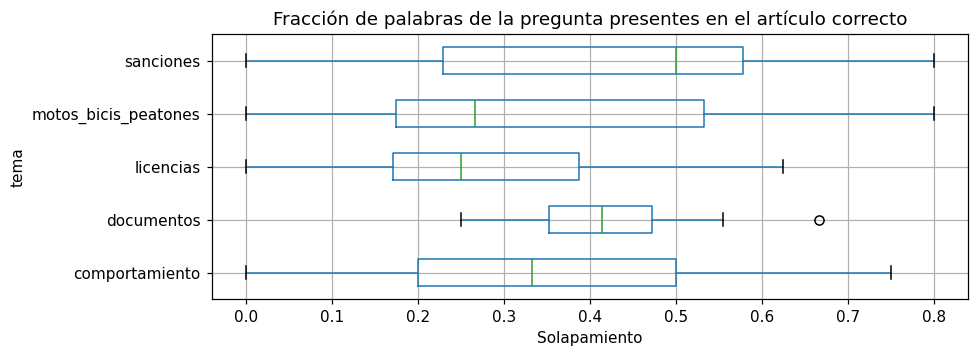

,pregunta,articulos_gold,solapamiento
0,¿Desde qué edad puedo sacar el pase para manejar un carro particular?,{19},0.0
23,¿Qué tengo que hacer si viene detrás una ambulancia con la sirena prendida?,{64},0.0
30,¿Las motos pueden andar por la ciclorruta?,{68},0.0
38,¿Qué me pasa si me cogen manejando borracho?,"{152, 26}",0.0
41,¿Qué significa que me inmovilicen el carro y a dónde se lo llevan?,{125},0.0


In [13]:
VACIAS = set("""
a al algo algún alguna como con cual cuál cuales cuando cuándo cuánto cuánta cuántos de del desde donde dónde el
en es esa ese eso esta este esto hay la las lo los me mi mis más o para pero por que qué quien quién se si sí sin
su sus también tengo tiene un una uno y ya yo le les muy puedo pueden debo hacer hago son está están
""".split())


def palabras_contenido(texto):
    sin_tildes = unicodedata.normalize('NFKD', texto.lower()).encode('ascii', 'ignore').decode()
    return {p for p in re.findall(r'[a-zñ]+', sin_tildes) if len(p) > 2 and p not in VACIAS}


texto_por_articulo = dict(zip(vigentes.articulo, vigentes.texto + ' ' + vigentes.nombre))
en_dominio['solapamiento'] = [
    len(palabras_contenido(q) & palabras_contenido(' '.join(texto_por_articulo[a] for a in gold))) /
    max(len(palabras_contenido(q)), 1)
    for q, gold in zip(en_dominio.pregunta, en_dominio.articulos_gold)]

print(f'Solapamiento léxico medio: {en_dominio.solapamiento.mean():.1%}')
fig, eje = plt.subplots(figsize=(9, 3.5))
en_dominio.boxplot(column='solapamiento', by='tema', ax=eje, vert=False)
eje.set_title('Fracción de palabras de la pregunta presentes en el artículo correcto')
eje.set_xlabel('Solapamiento')
plt.suptitle('')
plt.tight_layout()
plt.show()
en_dominio.nsmallest(5, 'solapamiento')[['pregunta', 'articulos_gold', 'solapamiento']]

**Lo que observamos.** En promedio, solo el 37,3 % de las palabras de una pregunta aparece en su artículo correcto, y cinco preguntas no comparten ninguna palabra con él. La gente dice "pase", "borracho", "motos" o "que me inmovilicen", y la ley dice "licencia de conducción", "embriaguez", "motocicletas" e "inmovilización". Las preguntas de sanciones son las que más se parecen al texto de la ley (mediana cercana a 0,5) y las de licencias las que menos (alrededor de 0,25). Esto confirma que necesitamos embeddings que capten el significado; una búsqueda por coincidencia de palabras fallaría en varias de estas preguntas.

---
## 8. Experimentos de recuperación

Combinamos las tres estrategias de fragmentación con cuatro variantes de embeddings:

| Variante | Modelo | Por qué la incluimos |
|---|---|---|
| e5-large sin prefijos | `intfloat/multilingual-e5-large` | Uso directo del modelo, sin ninguna instrucción adicional |
| e5-large con prefijos | `intfloat/multilingual-e5-large` | La forma recomendada por sus autores: `query:` en la pregunta y `passage:` en el texto |
| e5-base con prefijos | `intfloat/multilingual-e5-base` | La mitad de parámetros: ¿cuánto se pierde con un modelo más liviano? |
| bge-m3 | `BAAI/bge-m3` | Modelo multilingüe más reciente, que admite textos largos. Lo limitamos a 1.024 tokens para no quedarnos sin memoria en la T4 |

Cada combinación se indexa en FAISS con producto interno sobre vectores normalizados (equivale a similitud coseno). Para cada pregunta recuperamos 20 candidatos y los evaluamos de dos formas: en el orden que da FAISS, y reordenados con el cross-encoder `BAAI/bge-reranker-v2-m3`, que lee la pregunta y el fragmento juntos en lugar de comparar dos vectores independientes. Guardamos los 20 candidatos con su texto y sus puntajes, así podemos calcular las métricas para cualquier k sin repetir búsquedas, y también reutilizarlos después para calibrar el umbral de abstención.

Además del acierto medimos el **costo**: cuántas palabras de contexto recibe el modelo generador con k = 5. Una estrategia que acierta igual pero entrega la mitad del texto es preferible, porque los modelos pequeños se confunden con contextos largos.


In [14]:
from langchain_community.cross_encoders import HuggingFaceCrossEncoder
from langchain_community.vectorstores import FAISS
from langchain_community.vectorstores.utils import DistanceStrategy
from langchain_huggingface import HuggingFaceEmbeddings

MODELOS_EMBEDDING = {
    'e5-large sin prefijos': {'modelo': 'intfloat/multilingual-e5-large', 'consulta': '', 'pasaje': ''},
    'e5-large con prefijos': {'modelo': 'intfloat/multilingual-e5-large', 'consulta': 'query: ', 'pasaje': 'passage: '},
    'e5-base con prefijos': {'modelo': 'intfloat/multilingual-e5-base', 'consulta': 'query: ', 'pasaje': 'passage: '},
    'bge-m3': {'modelo': 'BAAI/bge-m3', 'consulta': '', 'pasaje': '', 'max_tokens': 1024},
}
RERANKER_MODELO = 'BAAI/bge-reranker-v2-m3'
K_CANDIDATOS = 20
KS = (1, 3, 5, 10)


def crear_embeddings(cfg):
    base = {'normalize_embeddings': True, 'batch_size': 16}
    embeddings = HuggingFaceEmbeddings(
        model_name=cfg['modelo'], model_kwargs={'device': DEVICE},
        encode_kwargs={**base, **({'prompt': cfg['pasaje']} if cfg['pasaje'] else {})},
        query_encode_kwargs={**base, **({'prompt': cfg['consulta']} if cfg['consulta'] else {})})
    if 'max_tokens' in cfg:
        embeddings._client.max_seq_length = cfg['max_tokens']
    return embeddings


def crear_indice(documentos, embeddings):
    return FAISS.from_documents(documentos, embeddings, distance_strategy=DistanceStrategy.MAX_INNER_PRODUCT)


def liberar_memoria():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


reranker = HuggingFaceCrossEncoder(model_name=RERANKER_MODELO, model_kwargs={'device': DEVICE, 'max_length': 512})
print('Re-ranker cargado:', RERANKER_MODELO)

config.json:   0%|          | 0.00/795 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 2.27GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/1.17k [00:00<?, ?B/s]

...

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.1MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

Re-ranker cargado: BAAI/bge-reranker-v2-m3


In [15]:
candidatos, tiempos = [], []
for nombre_emb, cfg in MODELOS_EMBEDDING.items():
    inicio = time.time()
    embeddings = crear_embeddings(cfg)
    carga = time.time() - inicio
    for nombre_frag, documentos in FRAGMENTOS.items():
        inicio = time.time()
        indice = crear_indice(documentos, embeddings)
        indexacion = time.time() - inicio
        inicio = time.time()
        for fila in preguntas.itertuples():
            resultados = indice.similarity_search_with_score(fila.pregunta, k=K_CANDIDATOS)
            puntajes = reranker.score([(fila.pregunta, doc.page_content) for doc, _ in resultados])
            for posicion, ((doc, similitud), puntaje) in enumerate(zip(resultados, puntajes)):
                candidatos.append({'embedding': nombre_emb, 'estrategia': nombre_frag, 'id': fila.id,
                                   'posicion': posicion, 'articulo': doc.metadata['articulo'],
                                   'similitud': float(similitud), 'puntaje_reranker': float(puntaje),
                                   'palabras': contar_palabras(doc.page_content), 'texto': doc.page_content})
        tiempos.append({'embedding': nombre_emb, 'estrategia': nombre_frag, 'carga_modelo_s': carga,
                        'indexacion_s': indexacion, 'busqueda_y_reranking_s': time.time() - inicio})
        print(f'{nombre_emb:22s} | {nombre_frag:11s} | {len(documentos):4d} fragmentos | '
              f'indexación {indexacion:5.1f} s')
    del embeddings, indice
    liberar_memoria()

candidatos = pd.DataFrame(candidatos)
pd.DataFrame(tiempos).round(1)

modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/160k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/690 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 2.24GB            

...

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

bge-m3                 | articulo    |  176 fragmentos | indexación   9.7 s
bge-m3                 | ventana     |  524 fragmentos | indexación  16.8 s
bge-m3                 | estructural |  354 fragmentos | indexación  11.0 s


,embedding,estrategia,carga_modelo_s,indexacion_s,busqueda_y_reranking_s
0,e5-large sin prefijos,articulo,24.5,8.0,85.5
1,e5-large sin prefijos,ventana,24.5,16.7,42.0
2,e5-large sin prefijos,estructural,24.5,11.0,55.3
3,e5-large con prefijos,articulo,6.6,7.7,91.7
4,e5-large con prefijos,ventana,6.6,17.0,41.8
5,e5-large con prefijos,estructural,6.6,11.3,55.8
6,e5-base con prefijos,articulo,18.9,2.5,93.0
7,e5-base con prefijos,ventana,18.9,5.4,41.9
8,e5-base con prefijos,estructural,18.9,3.5,59.3
9,bge-m3,articulo,60.4,9.7,94.7


Con los candidatos guardados calculamos las métricas. Para la versión con re-ranking ordenamos los 20 candidatos de cada pregunta por el puntaje del cross-encoder; sin re-ranking conservamos el orden de FAISS. Para la Evidencia@k revisamos el texto de cada uno de los k primeros fragmentos.

In [16]:
gold_por_id = dict(zip(preguntas.id, preguntas.articulos_gold))
evidencia_por_id = dict(zip(preguntas.id, preguntas.evidencia))
ids_en_dominio = set(en_dominio.id)


def metricas_ranking(articulos, textos, gold, evidencia):
    fila = {f'recall@{k}': len(set(articulos[:k]) & gold) / len(gold) for k in KS}
    fila.update({f'evidencia@{k}': float(any(contiene_evidencia(t, evidencia) for t in textos[:k])) for k in KS})
    fila['mrr@10'] = next((1 / (i + 1) for i, a in enumerate(articulos[:10]) if a in gold), 0.0)
    return fila


filas = []
for (nombre_emb, nombre_frag, qid), grupo in candidatos[candidatos.id.isin(ids_en_dominio)].groupby(
        ['embedding', 'estrategia', 'id'], sort=False):
    for con_reranker in (False, True):
        orden = grupo.sort_values('puntaje_reranker' if con_reranker else 'posicion', ascending=not con_reranker)
        fila = metricas_ranking(orden['articulo'].tolist(), orden['texto'].tolist(), gold_por_id[qid],
                                evidencia_por_id[qid])
        fila.update({'embedding': nombre_emb, 'estrategia': nombre_frag, 'reranker': con_reranker, 'id': qid,
                     'palabras_contexto@5': orden['palabras'].head(5).sum()})
        filas.append(fila)

por_pregunta = pd.DataFrame(filas)
COLUMNAS_METRICAS = ([f'recall@{k}' for k in KS] + ['mrr@10'] + [f'evidencia@{k}' for k in KS] +
                     ['palabras_contexto@5'])
tabla_recuperacion = (por_pregunta.groupby(['embedding', 'estrategia', 'reranker'], sort=False)[COLUMNAS_METRICAS]
                      .mean().round(3))
tabla_recuperacion.sort_values(['evidencia@5', 'recall@5', 'mrr@10'], ascending=False).head(12)

recall@1  recall@3  recall@5  \
embedding             estrategia  reranker                                 
e5-large sin prefijos estructural True         0.870     0.989     0.989   
e5-large con prefijos estructural True         0.870     0.989     0.989   
bge-m3                estructural True         0.870     0.989     0.989   
                                  False        0.793     0.946     0.989   
e5-base con prefijos  estructural True         0.870     0.967     0.967   
bge-m3                articulo    True         0.804     0.913     0.946   
e5-large sin prefijos articulo    True         0.804     0.935     0.946   
e5-large con prefijos articulo    True         0.804     0.935     0.946   
bge-m3                articulo    False        0.696     0.924     0.946   
                      ventana     True         0.891     0.989     0.989   
e5-base con prefijos  articulo    True         0.783     0.913     0.924   
e5-large sin prefijos ventana     True         0.870     0.967     0.967   

                                            recall@10  mrr@10  evidencia@1  \
embedding             estrategia  reranker                                   
e5-large sin prefijos estructural True          1.000   0.946        0.804   
e5-large con prefijos estructural True          1.000   0.946        0.804   
bge-m3                estructural True          0.989   0.946        0.804   
                                  False         0.989   0.899        0.739   
e5-base con prefijos  estructural True          0.978   0.935        0.804   
bge-m3                articulo    True          0.978   0.879        0.826   
e5-large sin prefijos articulo    True          0.957   0.878        0.826   
e5-large con prefijos articulo    True          0.957   0.878        0.826   
bge-m3                articulo    False         0.967   0.827        0.696   
                      ventana     True          1.000   0.953        0.848   
e5-base con prefijos  articulo    True          0.957   0.859        0.804   
e5-large sin prefijos ventana     True          0.978   0.931        0.826   

                                            evidencia@3  evidencia@5  \
embedding             estrategia  reranker                             
e5-large sin prefijos estructural True            0.978        1.000   
e5-large con prefijos estructural True            0.978        1.000   
bge-m3                estructural True            0.957        1.000   
                                  False           0.913        0.978   
e5-base con prefijos  estructural True            0.935        0.978   
bge-m3                articulo    True            0.913        0.957   
e5-large sin prefijos articulo    True            0.935        0.957   
e5-large con prefijos articulo    True            0.935        0.957   
bge-m3                articulo    False           0.935        0.957   
                      ventana     True            0.913        0.935   
e5-base con prefijos  articulo    True            0.913        0.935   
e5-large sin prefijos ventana     True            0.891        0.913   

                                            evidencia@10  palabras_contexto@5  
embedding             estrategia  reranker                                     
e5-large sin prefijos estructural True             1.000              604.478  
e5-large con prefijos estructural True             1.000              610.174  
bge-m3                estructural True             1.000              601.152  
                                  False            1.000              607.630  
e5-base con prefijos  estructural True             0.978              609.022  
bge-m3                articulo    True             0.978             1365.587  
e5-large sin prefijos articulo    True             0.957             1340.130  
e5-large con prefijos articulo    True             0.957             1294.043  
bge-m3                articulo    False            0.978             1412.435

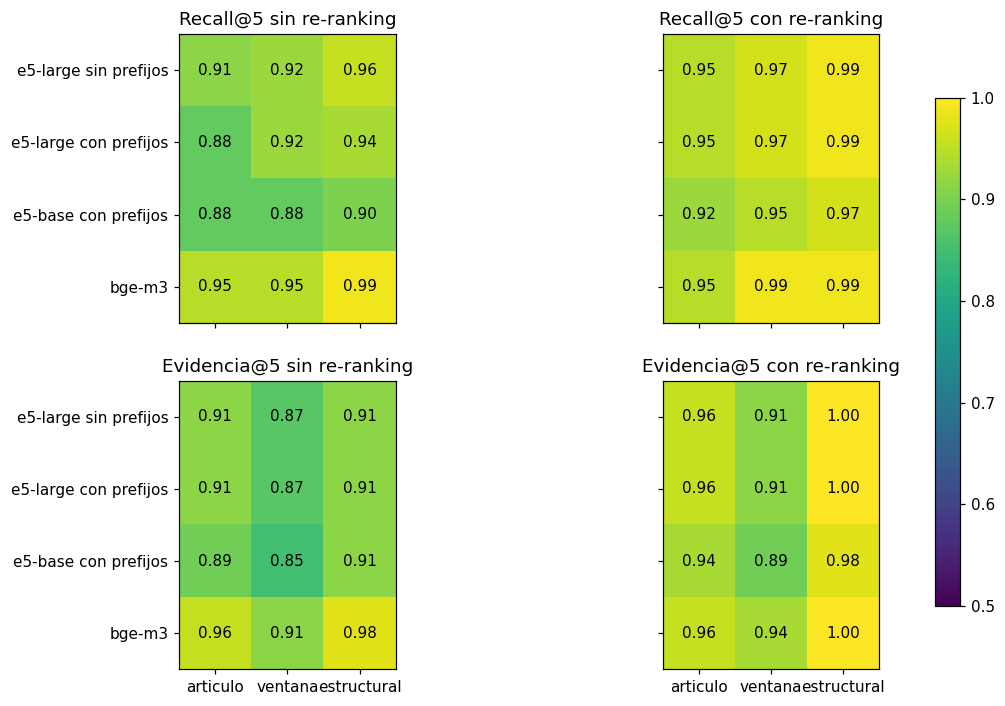

In [17]:
fig, ejes = plt.subplots(2, 2, figsize=(13, 7.5), sharex=True, sharey=True)
for fila_ejes, metrica in zip(ejes, ('recall@5', 'evidencia@5')):
    for eje, con_reranker in zip(fila_ejes, (False, True)):
        matriz = tabla_recuperacion.xs(con_reranker, level='reranker')[metrica].unstack('estrategia')
        matriz = matriz.loc[list(MODELOS_EMBEDDING), list(ESTRATEGIAS)]
        imagen = eje.imshow(matriz.values, cmap='viridis', vmin=0.5, vmax=1)
        eje.set_xticks(range(matriz.shape[1]), matriz.columns)
        eje.set_yticks(range(matriz.shape[0]), matriz.index)
        for i in range(matriz.shape[0]):
            for j in range(matriz.shape[1]):
                eje.text(j, i, f'{matriz.values[i, j]:.2f}', ha='center', va='center',
                         color='white' if matriz.values[i, j] < 0.8 else 'black')
        eje.set_title(f'{metrica.capitalize()} {"con" if con_reranker else "sin"} re-ranking')
fig.colorbar(imagen, ax=ejes, shrink=0.8)
plt.show()

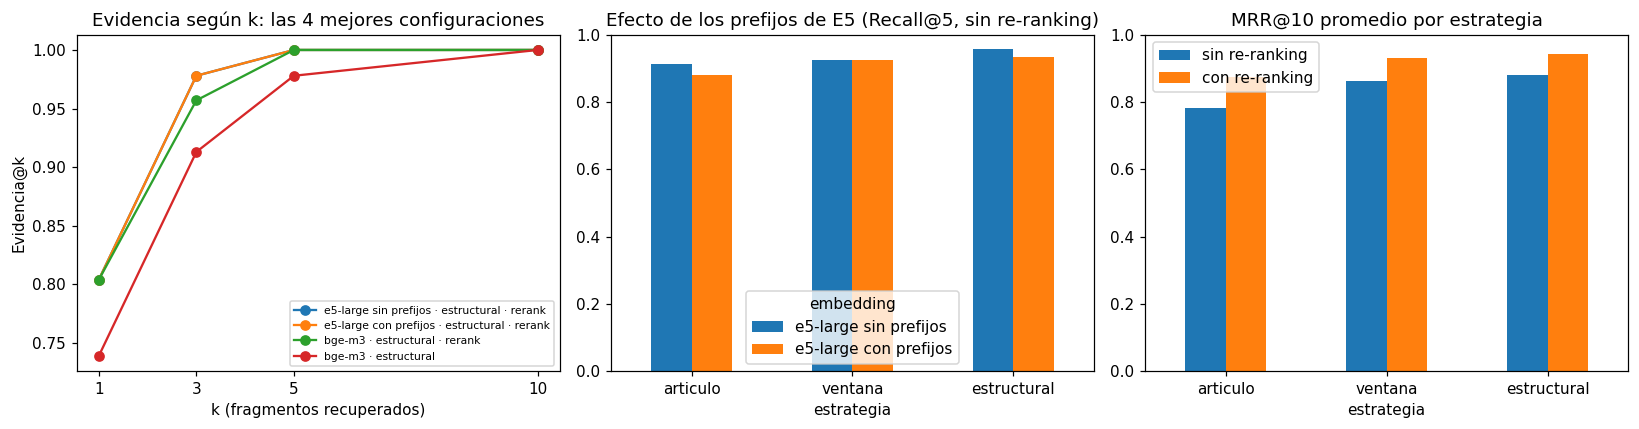

recall@5  evidencia@5  mrr@10  palabras_contexto@5
estrategia  reranker                                                    
articulo    False        0.905        0.918   0.782             1112.821
            True         0.940        0.952   0.874             1353.646
ventana     False        0.918        0.875   0.862              565.886
            True         0.967        0.913   0.931              572.647
estructural False        0.946        0.929   0.879              586.070
            True         0.984        0.994   0.943              606.206

In [18]:
fig, ejes = plt.subplots(1, 3, figsize=(15, 4))

mejores = tabla_recuperacion.sort_values(['evidencia@5', 'recall@5', 'mrr@10'], ascending=False).head(4)
for (nombre_emb, nombre_frag, con_reranker), fila in mejores.iterrows():
    etiqueta = f'{nombre_emb} · {nombre_frag}{" · rerank" if con_reranker else ""}'
    ejes[0].plot(KS, [fila[f'evidencia@{k}'] for k in KS], marker='o', label=etiqueta)
ejes[0].set_xticks(KS)
ejes[0].set_xlabel('k (fragmentos recuperados)')
ejes[0].set_ylabel('Evidencia@k')
ejes[0].set_title('Evidencia según k: las 4 mejores configuraciones')
ejes[0].legend(fontsize=7)

prefijos = (tabla_recuperacion.xs(False, level='reranker')
            .loc[['e5-large sin prefijos', 'e5-large con prefijos'], 'recall@5'].unstack('embedding'))
prefijos.loc[list(ESTRATEGIAS)].plot.bar(ax=ejes[1], rot=0)
ejes[1].set_title('Efecto de los prefijos de E5 (Recall@5, sin re-ranking)')
ejes[1].set_ylim(0, 1)

efecto = tabla_recuperacion['mrr@10'].unstack('reranker')
efecto.columns = ['sin re-ranking', 'con re-ranking']
efecto.groupby(level='estrategia').mean().loc[list(ESTRATEGIAS)].plot.bar(ax=ejes[2], rot=0)
ejes[2].set_title('MRR@10 promedio por estrategia')
ejes[2].set_ylim(0, 1)
plt.tight_layout()
plt.show()

(tabla_recuperacion.groupby(level=['estrategia', 'reranker'])[['recall@5', 'evidencia@5', 'mrr@10', 'palabras_contexto@5']]
 .mean().round(3).loc[list(ESTRATEGIAS)])

### Lo que encontramos en la recuperación

**H1 (fragmentación estructural): se cumple.** Con re-ranking y promediando los cuatro embeddings, la estrategia estructural obtiene 0,984 de Recall@5, 0,994 de Evidencia@5 y 0,943 de MRR@10, las mejores cifras en las tres métricas. Las otras dos estrategias fallan de formas distintas:

- **Ventana.** Encuentra bien el artículo (0,967 de Recall@5 con re-ranking), pero tiene la peor Evidencia@5 (0,913 con re-ranking y 0,875 sin él). Al cortar cada 100 palabras, el literal "D.4" puede quedar en una ventana y el párrafo que dice "treinta (30) SMLDV" en otra. El Recall no ve este problema; la Evidencia sí.
- **Artículo completo.** Tiene la peor MRR@10 (0,782 sin re-ranking) y entrega más del doble de contexto: 1.354 palabras con k = 5 y re-ranking, frente a unas 600 de las otras dos. Su Evidencia@5 no es mala (0,952 con re-ranking) porque el artículo entero siempre contiene la frase, pero el generador tendría que buscarla en textos de hasta 3.000 palabras.

**H2 (prefijos de E5): no se cumple.** Sin re-ranking, e5-large sin prefijos obtiene un Recall@5 igual o mayor que con prefijos: 0,91 frente a 0,88 con artículo completo, 0,92 frente a 0,92 con ventana y 0,96 frente a 0,94 con estructural. La Evidencia@5 es idéntica en las tres estrategias, y con re-ranking la diferencia desaparece. Una posible explicación es que el encabezado de cada fragmento ya le da al modelo el contexto que buscan aportar los prefijos. De todos modos, con 46 preguntas una diferencia de 0,02 o 0,03 equivale a una o dos preguntas, así que no la tomamos como una ventaja real de ninguna de las dos formas.

**H3 (re-ranking): se cumple.** El cross-encoder sube la MRR@10 en las tres estrategias:

| Estrategia | MRR@10 sin re-ranking | MRR@10 con re-ranking |
|---|---|---|
| Artículo completo | 0,782 | 0,874 |
| Ventana | 0,862 | 0,931 |
| Estructural | 0,879 | 0,943 |

También sube la Evidencia@5; con fragmentación estructural pasa de 0,929 a 0,994. El costo es tiempo: buscar y reordenar 20 candidatos para las 52 preguntas tomó entre 41 s (ventana) y 95 s (artículo completo) por configuración, porque el cross-encoder lee cada fragmento completo junto con la pregunta.

**Sobre los modelos de embeddings.** `bge-m3` es el mejor sin re-ranking: con fragmentación estructural logra 0,99 de Recall@5 y 0,98 de Evidencia@5, así que es el que menos depende del cross-encoder. `e5-base`, con la mitad de parámetros, queda sin re-ranking entre 0 y 6 puntos por debajo de `e5-large` e indexa unas tres veces más rápido (3,5 s frente a 11 s con estructural). Con re-ranking las diferencias entre embeddings casi desaparecen, porque el cross-encoder corrige buena parte del orden inicial.

En la curva de la izquierda, las tres mejores configuraciones llegan a una Evidencia@5 de 1,0. Con k = 3, las dos de e5-large llegan a 0,978 y la de bge-m3 a 0,957. La cuarta curva, bge-m3 con estructural sin re-ranking, empieza en 0,739 con k = 1, lo que muestra otra vez que el re-ranking mejora sobre todo las primeras posiciones.

### Selección de la configuración final

Elegimos la configuración con mayor Evidencia@5, porque lo que necesita el modelo generador es que el fragmento traiga la respuesta, no solo que pertenezca al artículo correcto. Si hay empate desempatamos con Recall@5, luego con MRR@10 y, por último, con la que entregue menos palabras de contexto. Después fijamos k con una regla sencilla: el menor k cuya Evidencia@k llega al 95 % de la Evidencia@10 de esa configuración. Así no le pasamos al modelo más contexto del necesario.

In [19]:
(EMB_FINAL, ESTRATEGIA_FINAL, RERANKER_FINAL), fila_final = next(
    tabla_recuperacion.sort_values(['evidencia@5', 'recall@5', 'mrr@10', 'palabras_contexto@5'],
                                   ascending=[False, False, False, True]).iterrows())
K_FINAL = next(k for k in KS if fila_final[f'evidencia@{k}'] >= 0.95 * fila_final['evidencia@10'])

print('Embedding:', EMB_FINAL)
print('Estrategia de fragmentación:', ESTRATEGIA_FINAL)
print('Re-ranking:', 'sí' if RERANKER_FINAL else 'no')
print('k:', K_FINAL)
print(fila_final.round(3).to_string())

fallos = por_pregunta[(por_pregunta.embedding == EMB_FINAL) & (por_pregunta.estrategia == ESTRATEGIA_FINAL) &
                      (por_pregunta.reranker == RERANKER_FINAL) & (por_pregunta[f'evidencia@{K_FINAL}'] < 1)]
print(f'\nPreguntas sin la evidencia entre los {K_FINAL} fragmentos recuperados: {len(fallos)}')
fallos.merge(preguntas[['id', 'pregunta', 'articulos_gold', 'evidencia']], on='id')[
    ['pregunta', 'articulos_gold', 'evidencia', f'recall@{K_FINAL}', 'mrr@10']]

Embedding: bge-m3
Estrategia de fragmentación: estructural
Re-ranking: sí
k: 3
recall@1                 0.870
recall@3                 0.989
recall@5                 0.989
recall@10                0.989
mrr@10                   0.946
evidencia@1              0.804
evidencia@3              0.957
evidencia@5              1.000
evidencia@10             1.000
palabras_contexto@5    601.152

Preguntas sin la evidencia entre los 3 fragmentos recuperados: 2


,pregunta,articulos_gold,evidencia,recall@3,mrr@10
0,¿Qué papeles y exámenes me piden para sacar la licencia de conducción por primera vez?,{19},[Aprobar exámenes teórico y práctico],1.0,0.5
1,¿Qué tipos de sanciones me pueden poner por una infracción de tránsito?,{122},[Amonestación],1.0,1.0


**Lo que observamos.** Tres configuraciones empatan en Evidencia@5 (1,0), Recall@5 (0,989) y MRR@10 (0,946): las dos de e5-large y la de bge-m3, todas con fragmentación estructural y re-ranking. El desempate por contexto elige bge-m3, que entrega 601 palabras frente a 604 y 610. Es una diferencia tan pequeña que en la práctica las tres configuraciones son equivalentes. Con la regla del 95 % el k elegido es 3, porque una Evidencia@3 de 0,957 ya supera ese límite. Vale la pena reconocer un detalle: con k = 3, e5-large habría fallado en una pregunta menos (0,978), pero nuestro criterio compara primero con k = 5, y la diferencia es de una sola pregunta.

Las dos preguntas que se quedan sin evidencia con k = 3 sí tienen el artículo correcto entre los recuperados (Recall@3 = 1), pero no el pedazo que responde:

- **Requisitos de la licencia.** El primer fragmento del artículo 19 aparece en la segunda posición, pero ninguno de los tres fragmentos incluye "Aprobar exámenes teórico y práctico".
- **Tipos de sanciones.** El artículo 122 aparece en la primera posición, pero el fragmento recuperado no es el de la lista donde está la amonestación.

Son artículos largos (439 y 875 palabras) partidos en varios fragmentos, justo el caso que el Recall no detecta.

---
## 9. Modelos generadores con Ollama

Comparamos dos modelos pequeños que caben sin problema en una T4: `llama3.2:3b` (Meta) y `gemma3:4b` (Google). Ambos trabajan con temperatura 0 y semilla fija para que las respuestas sean repetibles, con una ventana de contexto de 8.192 tokens para que los fragmentos no se trunquen y con un máximo de 512 tokens por respuesta, para que un modelo que entre en un bucle no bloquee la ejecución.

In [20]:
def ollama_activo(host='127.0.0.1', puerto=11434):
    with socket.socket() as conexion:
        conexion.settimeout(1)
        return conexion.connect_ex((host, puerto)) == 0


if shutil.which('ollama') is None:
    if not IN_COLAB:
        raise RuntimeError('Instala Ollama desde https://ollama.com/download y vuelve a ejecutar la celda.')
    # El instalador de Ollama necesita zstd para descomprimir el binario.
    !sudo apt-get install -y -qq zstd > /dev/null
    !curl -fsSL https://ollama.com/install.sh | sh

if not ollama_activo():
    servidor_ollama = subprocess.Popen(['ollama', 'serve'], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    for _ in range(60):
        if ollama_activo():
            break
        time.sleep(1)
print('Servidor de Ollama activo:', ollama_activo())

debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 79, <STDIN> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Creating ollama user...
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.
Servidor de Ollama activo: True


In [21]:
from langchain_ollama import ChatOllama

LLMS = ['llama3.2:3b', 'gemma3:4b']
for modelo in LLMS:
    inicio = time.time()
    subprocess.run(['ollama', 'pull', modelo], check=True, capture_output=True)
    print(f'{modelo} listo en {time.time() - inicio:.0f} s')


def crear_llm(modelo):
    return ChatOllama(model=modelo, temperature=0, seed=SEED, num_ctx=8192, num_predict=512,
                      validate_model_on_init=True)


def descargar_de_memoria(modelo):
    subprocess.run(['ollama', 'stop', modelo], capture_output=True)

llama3.2:3b listo en 36 s
gemma3:4b listo en 42 s


Antes de conectar la recuperación, vale la pena ver qué responden los modelos **sin contexto**, solo con lo que aprendieron en su entrenamiento. Les pedimos además que citen el artículo, para ver si lo inventan.

In [22]:
PREGUNTAS_SIN_CONTEXTO = [16, 35, 38]
for modelo in LLMS:
    llm = crear_llm(modelo)
    print('=' * 100, f'\n{modelo}')
    for qid in PREGUNTAS_SIN_CONTEXTO:
        pregunta = preguntas.loc[preguntas.id == qid, 'pregunta'].iloc[0]
        respuesta = llm.invoke(f'{pregunta} Responde en máximo tres frases y cita el artículo de la Ley 769 de '
                               f'2002 (Código Nacional de Tránsito de Colombia) que lo establece.').content
        print(f'\n• {pregunta}  [artículos correctos: {sorted(gold_por_id[qid])}]\n{respuesta}')
    descargar_de_memoria(modelo)

llama3.2:3b

• ¿Un niño de 8 años puede ir sentado en el puesto de adelante?  [artículos correctos: ['82']]
Lo siento, pero no tengo información específica sobre la Ley 769 de 2002 (Código Nacional de Tránsito de Colombia) que establezca la edad mínima para sentarse en el puesto de adelante en un vehículo. Sin embargo, en general, se recomienda que los niños menores de 12 años no deben sentarse en el puesto de adelante en un vehículo, ya que pueden no tener la visión clara o la capacidad para reaccionar rápidamente en caso de emergencia.

• ¿De cuánto es la multa por pasarme un semáforo en rojo?  [artículos correctos: ['131']]
Lo siento, pero no tengo acceso a información específica sobre multas por pasarse un semáforo en rojo en Colombia. Sin embargo, puedo decirte que en muchos países, la multa por pasarse un semáforo en rojo puede variar dependiendo de la jurisdicción y las circunstancias del incidente.

En Colombia, la Ley 769 de 2002 (Código Nacional de Tránsito) establece que "qu

**Lo que observamos.** Sin contexto, ninguno de los dos modelos cita los artículos correctos (82, 131 y 159).

- **`llama3.2:3b`** dice en las tres preguntas que no tiene la información, pero en dos de ellas sigue respondiendo:
  - en la del niño agrega una recomendación general (que los menores de 12 años no vayan adelante) que no sale de la ley;
  - en la del semáforo inventa una cita del artículo 34 con una multa de "$1.000.000" que no aparece en la ley.
- **`gemma3:4b`** responde las tres con mucha seguridad y cita mal en todas:
  - en la del niño acierta en que no puede ir adelante, pero cita el artículo 20 en lugar del 82;
  - cita los artículos 205 y 290 para el semáforo y la prescripción, aunque la Ley 769 de 2002 termina en el artículo 170;
  - habla de multas en UVT, una unidad que no aparece en el texto de la ley que usamos;
  - dice que la multa no tiene un plazo de prescripción definido, cuando el artículo 159 la fija en tres años.

Esto es justo lo que queremos evitar con RAG: el modelo que suena más convincente es también el que más inventa cuando no tiene de dónde leer.

---
## 10. Cadena RAG con citas

Armamos la cadena con las piezas de LangChain `create_stuff_documents_chain` y `create_retrieval_chain`, y les agregamos tres piezas propias para este caso:

1. **Un recuperador propio (`RecuperadorLey`)** que busca en FAISS, reordena con el cross-encoder si la configuración elegida usa re-ranking, y guarda el puntaje de cada fragmento en sus metadatos (el del cross-encoder o, si no hay re-ranking, la similitud del embedding). Con ese puntaje mostramos la relevancia en la interfaz y aplicamos el umbral de abstención.
2. **Un atajo para cuando no hay contexto.** Si el recuperador no devuelve nada, porque ningún fragmento supera el umbral, la cadena responde un mensaje fijo sin llamar al modelo. Así el modelo no tiene oportunidad de inventar.
3. **Referencias armadas desde los metadatos.** Cada respuesta termina con la lista de artículos consultados, tomada de los metadatos de los fragmentos. No hace falta buscar el texto de vuelta en el corpus.

El prompt le pide al modelo que use solo el contexto, que cite con el formato "(Art. N)" y que, solo si ningún artículo le sirve, responda con una frase fija que podamos detectar automáticamente. También le advierte que las preguntas usan palabras coloquiales distintas a las de la ley. La gente dice "pase", "parquear" o "tanquear", mientras que la ley habla de licencia de conducción, estacionar y proveer de combustible, y un modelo pequeño tiende a decir que no encontró la información cuando el artículo no repite las palabras de la pregunta.

Contamos una respuesta como abstención solo cuando empieza con la frase fija. A veces el modelo responde bien y al final agrega la frase; en ese caso la quitamos y conservamos la respuesta con sus referencias.

In [23]:
from langchain_classic.chains import create_retrieval_chain
from langchain_classic.chains.combine_documents import create_stuff_documents_chain
from langchain_core.callbacks import CallbackManagerForRetrieverRun
from langchain_core.prompts import PromptTemplate
from langchain_core.retrievers import BaseRetriever
from langchain_core.runnables import RunnableBranch, RunnableLambda

MENSAJE_ABSTENCION = 'No encontré esa información en el Código Nacional de Tránsito.'


class RecuperadorLey(BaseRetriever):
    indice: Any
    reranker: Any = None
    k: int = 5
    k_candidatos: int = K_CANDIDATOS
    umbral: Optional[float] = None

    def _get_relevant_documents(self, query: str, *, run_manager: CallbackManagerForRetrieverRun):
        resultados = self.indice.similarity_search_with_score(query, k=self.k_candidatos if self.reranker else self.k)
        if self.reranker is not None:
            puntajes = self.reranker.score([(query, doc.page_content) for doc, _ in resultados])
            resultados = sorted(zip((doc for doc, _ in resultados), puntajes), key=lambda par: -par[1])
        documentos = [Document(page_content=doc.page_content, metadata={**doc.metadata, 'puntaje': float(p)})
                      for doc, p in resultados[:self.k]]
        if self.umbral is not None and (not documentos or documentos[0].metadata['puntaje'] < self.umbral):
            return []
        return documentos


INSTRUCCIONES = (
    'Eres un asistente que orienta a ciudadanos colombianos sobre el Código Nacional de Tránsito (Ley 769 de 2002).\n'
    'Responde en español, de forma clara y breve, usando únicamente la información de los artículos del contexto.\n'
    'Las preguntas suelen usar palabras coloquiales distintas a las de la ley: si un artículo del contexto trata el '
    'mismo tema con otras palabras, úsalo para responder.\n'
    'Cita siempre los artículos en los que te basas con el formato (Art. N).\n'
    'No inventes valores, plazos ni artículos.\n'
    'Solo si ningún artículo del contexto sirve para responder, responde únicamente con esta frase, sin agregar nada más:\n'
    f'"{MENSAJE_ABSTENCION}"')

PROMPT_QA = PromptTemplate.from_template(INSTRUCCIONES + '\n\nContexto:\n{context}\n\nPregunta: {input}\nRespuesta:')


def con_atajo_de_abstencion(cadena_documentos):
    return RunnableBranch((lambda entrada: not entrada['context'], RunnableLambda(lambda _: MENSAJE_ABSTENCION)),
                          cadena_documentos)


def crear_cadena_qa(llm, recuperador, prompt=PROMPT_QA):
    return create_retrieval_chain(recuperador, con_atajo_de_abstencion(create_stuff_documents_chain(llm, prompt)))


def referencias(contexto):
    vistos = {}
    for doc in contexto:
        vistos.setdefault(doc.metadata['articulo'], doc.metadata['nombre'])
    return [f'Art. {a} – {n}' if n else f'Art. {a}' for a, n in vistos.items()]


def se_abstuvo(texto):
    return texto.strip().lower().startswith('no encontré esa información')


def formatear_respuesta(respuesta):
    texto = respuesta['answer'].strip()
    if respuesta['context'] and not se_abstuvo(texto):
        texto = texto.replace(MENSAJE_ABSTENCION, '').strip()
        texto += '\n\n**Referencias (Ley 769 de 2002):**\n' + '\n'.join(
            f'- [{i}] {ref}' for i, ref in enumerate(referencias(respuesta['context']), 1))
    return texto

In [24]:
embeddings_final = crear_embeddings(MODELOS_EMBEDDING[EMB_FINAL])
indice_final = crear_indice(FRAGMENTOS[ESTRATEGIA_FINAL], embeddings_final)
recuperador = RecuperadorLey(indice=indice_final, reranker=reranker if RERANKER_FINAL else None, k=K_FINAL)

llm = crear_llm(LLMS[0])
cadena_qa = crear_cadena_qa(llm, recuperador)
respuesta = cadena_qa.invoke({'input': '¿Las motos pueden andar por la ciclorruta?'})
print(formatear_respuesta(respuesta))

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

No, según el artículo 68, se prohíbe el tránsito de motocicletas y motociclos por las ciclorrutas o ciclovías.

**Referencias (Ley 769 de 2002):**
- [1] Art. 68 – UTILIZACIÓN DE LOS CARRILES
- [2] Art. 94 – NORMAS GENERALES PARA BICICLETAS, TRICICLOS, MOTOCICLETAS, MOTOCICLOS Y MOTOTRICICLOS


---
## 11. Comparación de modelos generadores

Pasamos las 52 preguntas por la cadena con cada modelo, con la misma configuración de recuperación y todavía sin umbral. De cada respuesta extraemos los artículos citados con una expresión regular. Si la cita está en singular ("(Art. 131)", "artículo 82") tomamos un solo número, porque en "(Art. 26, 1)" el 1 es un numeral dentro del artículo y no otro artículo; solo leemos listas cuando la cita está en plural ("artículos 26 y 152", "Arts. 143 y 143A"). Con eso calculamos:

- **Citas correctas:** preguntas del código en las que el modelo cita al menos un artículo correcto.
- **Respuestas con cita:** preguntas del código en las que el modelo cita algún artículo.
- **Citas fuera del contexto:** respuestas que citan un artículo que no estaba entre los fragmentos recuperados. Es la señal más clara de que el modelo se inventó la referencia.
- **Abstención fuera de dominio:** preguntas por fuera del código en las que el modelo dice que no encontró la información (lo deseable).
- **Abstención indebida:** preguntas del código en las que el modelo dice que no encontró la información aunque sí está.
- **Abstención con evidencia en el contexto:** entre las preguntas del código cuyo contexto sí traía la frase de evidencia, en cuántas el modelo dijo que no encontró la información. Separa las fallas del generador de las fallas de la recuperación.
- **Latencia media** por respuesta, sin contar la primera llamada, en la que se carga el modelo.


In [25]:
NUMERO_ARTICULO = r'\d+(?:-\d+|\s?[A-Z](?![A-Za-záéíóúñ.\d]))?'
RE_CITA_PLURAL = re.compile(rf'\b(?:[Aa]rt[íi]culos|ARTÍCULOS|[Aa]rts\.)\s*((?:{NUMERO_ARTICULO}(?:\s*(?:,|y|e)\s*)?)+)')
RE_CITA_SINGULAR = re.compile(rf'\b(?:[Aa]rt[íi]culo|ARTÍCULO|[Aa]rt\.)\s*({NUMERO_ARTICULO})')
RE_NUMERO_CITA = re.compile(NUMERO_ARTICULO)


def articulos_citados(texto):
    plurales = {n for grupo in RE_CITA_PLURAL.findall(texto) for n in RE_NUMERO_CITA.findall(grupo)}
    return {n.replace(' ', '') for n in plurales | set(RE_CITA_SINGULAR.findall(texto))}


print(articulos_citados('Según el (Art. 131 C.38), el (Art. 26, 1) y los artículos 26 y 152, además del art. 85 A, '
                        'los Arts. 143 y 143A y el Artículo 93-2.'))

{'131', '143', '143A', '26', '85A', '152', '93-2'}


In [26]:
from ollama import ResponseError


def invocar_con_reintentos(cadena, entrada, intentos=3):
    # En la T4 el proceso de Ollama a veces se cae por falta de memoria; al reintentar lo vuelve a levantar.
    for intento in range(1, intentos + 1):
        try:
            return cadena.invoke(entrada)
        except ResponseError as error:
            if intento == intentos:
                raise
            print(f'Ollama falló ({error.status_code}); reintento {intento} de {intentos - 1}')
            liberar_memoria()
            time.sleep(10)


respuestas_llm = []
for modelo in LLMS:
    liberar_memoria()
    cadena = crear_cadena_qa(crear_llm(modelo), recuperador)
    invocar_con_reintentos(cadena, {'input': preguntas.pregunta.iloc[0]})
    for fila in preguntas.itertuples():
        inicio = time.time()
        salida = invocar_con_reintentos(cadena, {'input': fila.pregunta})
        respuestas_llm.append({'modelo': modelo, 'id': fila.id, 'en_dominio': fila.en_dominio,
                               'respuesta': salida['answer'], 'latencia_s': time.time() - inicio,
                               'citados': articulos_citados(salida['answer']),
                               'contexto': {d.metadata['articulo'] for d in salida['context']},
                               'evidencia_en_contexto': any(contiene_evidencia(d.page_content, fila.evidencia)
                                                            for d in salida['context']),
                               'puntaje_max': max((d.metadata['puntaje'] for d in salida['context']), default=None)})
    descargar_de_memoria(modelo)
    print(f'{modelo}: {sum(r["modelo"] == modelo for r in respuestas_llm)} respuestas')

respuestas_llm = pd.DataFrame(respuestas_llm)
respuestas_llm['gold'] = respuestas_llm.id.map(gold_por_id)
respuestas_llm['abstencion'] = respuestas_llm.respuesta.apply(se_abstuvo)
respuestas_llm['cita_correcta'] = [bool(c & g) for c, g in zip(respuestas_llm.citados, respuestas_llm.gold)]
respuestas_llm['con_cita'] = respuestas_llm.citados.apply(len) > 0
respuestas_llm['cita_fuera_contexto'] = [bool(c - ctx) for c, ctx in zip(respuestas_llm.citados, respuestas_llm.contexto)]


def resumir(grupo):
    dentro, fuera = grupo[grupo.en_dominio], grupo[~grupo.en_dominio]
    return pd.Series({
        'citas correctas': dentro.cita_correcta.mean(),
        'respuestas con cita': dentro.con_cita.mean(),
        'citas fuera del contexto': grupo.loc[grupo.con_cita, 'cita_fuera_contexto'].mean(),
        'abstención fuera de dominio': fuera.abstencion.mean(),
        'abstención indebida': dentro.abstencion.mean(),
        'abstención con evidencia en el contexto': dentro.loc[dentro.evidencia_en_contexto, 'abstencion'].mean(),
        'latencia media (s)': grupo.latencia_s.mean(),
    })


comparacion_llm = respuestas_llm.groupby('modelo').apply(resumir).loc[LLMS]
print(f'Preguntas del código con la evidencia en el contexto: '
      f'{respuestas_llm[respuestas_llm.en_dominio].groupby("modelo").evidencia_en_contexto.sum().iloc[0]} de {len(en_dominio)}')
comparacion_llm.round(3)


llama3.2:3b: 52 respuestas
gemma3:4b: 52 respuestas
Preguntas del código con la evidencia en el contexto: 44 de 46


,citas correctas,respuestas con cita,citas fuera del contexto,abstención fuera de dominio,abstención indebida,abstención con evidencia en el contexto,latencia media (s)
modelo,,,,,,,
llama3.2:3b,0.717,0.783,0.056,1.000,0.087,0.091,2.607
gemma3:4b,0.891,0.913,0.000,0.833,0.043,0.045,3.027


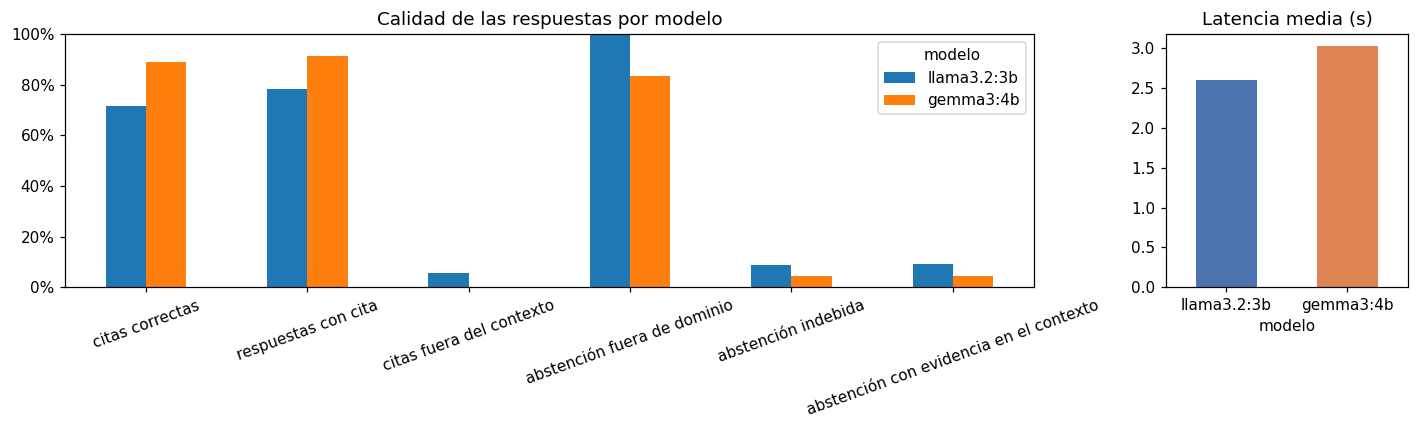

In [27]:
fig, ejes = plt.subplots(1, 2, figsize=(13, 4), gridspec_kw={'width_ratios': [4, 1]})
comparacion_llm.drop(columns='latencia media (s)').T.plot.bar(ax=ejes[0], rot=20)
ejes[0].set_ylim(0, 1)
ejes[0].set_title('Calidad de las respuestas por modelo')
ejes[0].yaxis.set_major_formatter(PercentFormatter(1.0))
comparacion_llm['latencia media (s)'].plot.bar(ax=ejes[1], rot=0, color=['#4C72B0', '#DD8452'])
ejes[1].set_title('Latencia media (s)')
plt.tight_layout()
plt.show()

Revisamos también algunas respuestas lado a lado: una sobre multas, una sobre comportamiento y una que el código no responde.

In [28]:
for qid in [35, 16, 49]:
    print('=' * 100)
    print(preguntas.loc[preguntas.id == qid, 'pregunta'].iloc[0], '| correctos:', sorted(gold_por_id[qid]) or '—')
    for modelo in LLMS:
        fila = respuestas_llm[(respuestas_llm.modelo == modelo) & (respuestas_llm.id == qid)].iloc[0]
        print(f'\n[{modelo}] citó {sorted(fila.citados) or "nada"} | contexto {sorted(fila.contexto)}')
        print(fila.respuesta)

¿De cuánto es la multa por pasarme un semáforo en rojo? | correctos: ['131']

[llama3.2:3b] citó nada | contexto ['131']
No encontré esa información en el Código Nacional de Tránsito.

[gemma3:4b] citó nada | contexto ['131']
D.4. No detenerse ante una luz roja de semáforo o una señal de "PARE" o un semáforo intermitente en rojo. Será sancionado con multa equivalente a treinta (30) salarios mínimos legales diarios vigentes (smldv).

¿Un niño de 8 años puede ir sentado en el puesto de adelante? | correctos: ['82']

[llama3.2:3b] citó ['82'] | contexto ['82', '84']
No, un niño de 8 años no puede ir sentado en el puesto de adelante porque, según el artículo 82, "Los menores de diez (10) años no podrán viajar en el asiento delantero del vehículo".

[gemma3:4b] citó ['82'] | contexto ['82', '84']
En el asiento delantero de los vehículos, solo podrán viajar, además del conductor, una (1) o dos (2) personas de acuerdo con las características de ellos. Los menores de diez (10) años no podrán v

In [29]:
LLM_FINAL = (comparacion_llm.assign(latencia=-comparacion_llm['latencia media (s)'])
             .sort_values(['citas correctas', 'abstención fuera de dominio', 'latencia'], ascending=False).index[0])
print('Modelo generador elegido para el chatbot:', LLM_FINAL)

Modelo generador elegido para el chatbot: gemma3:4b


### Lo que encontramos en la comparación de modelos

De las 46 preguntas del código, 44 llegaron al modelo con la frase de evidencia dentro del contexto. Las dos restantes son las que la recuperación no resolvió con k = 3.

**H4 (`gemma3:4b` cita mejor): se cumple en calidad, y el costo en velocidad es pequeño.** Con el mismo contexto, `gemma3:4b` le gana a `llama3.2:3b` en casi todas las medidas:

| Medida | `gemma3:4b` | `llama3.2:3b` |
|---|---|---|
| Preguntas del código con al menos una cita correcta | 41 de 46 (0,891) | 33 de 46 (0,717) |
| Respuestas con cita que nombran un artículo que no estaba en el contexto | ninguna | 5,6 % |
| Abstenciones indebidas en preguntas del código | 2 | 4 |
| Abstenciones con la evidencia en el contexto (de 44) | 2 (4,5 %) | 4 (9,1 %) |
| Latencia media por respuesta | 3,0 s | 2,6 s |

La diferencia de latencia es de apenas 0,4 s por respuesta.

La única medida en la que gana `llama3.2:3b` es la abstención fuera de dominio: rechazó las 6 preguntas externas, mientras que `gemma3:4b` rechazó 5. La que `gemma3:4b` respondió fue la de los requisitos de Uber, a la que contestó con los requisitos de la licencia de conducción del artículo 19. La respuesta suena razonable, pero no contesta lo que se preguntó, porque el código no regula las plataformas. Este caso muestra que la instrucción del prompt no basta y que vale la pena el umbral de la sección 12.

Las respuestas lado a lado muestran que la métrica de citas es estricta:

- **Semáforo en rojo.** `gemma3:4b` responde bien (literal D.4, multa de treinta SMLDV), pero no escribe "(Art. 131)", así que no se cuenta como cita correcta. En el chatbot el artículo 131 sí aparece en las referencias, porque estas se arman desde los metadatos. `llama3.2:3b`, con el mismo fragmento, dice que no encontró la información.
- **Niño de 8 años en el puesto de adelante.** Los dos modelos responden bien y citan el artículo 82.

Por estos resultados elegimos `gemma3:4b` para el chatbot.

---
## 12. Umbral de abstención

La instrucción de "no inventar" depende de que el modelo la obedezca. Queremos una segunda barrera que no dependa del modelo: si ni siquiera el fragmento más relevante tiene un puntaje alto, lo más probable es que la pregunta no esté en el código, y es mejor no llamar al generador.

Para calibrarlo tomamos el puntaje máximo de cada pregunta con la configuración final y comparamos su distribución entre las preguntas del código y las de fuera. Como umbral elegimos el valor que maximiza la **exactitud balanceada**: el promedio entre la fracción de preguntas del código que se aceptan y la fracción de preguntas externas que se rechazan. Si hay empate, preferimos el umbral más bajo, para no rechazar preguntas válidas.

Luego combinamos el umbral con las respuestas del modelo elegido: una respuesta se cuenta como abstención si el umbral la bloquea o si el modelo mismo dice que no encontró la información. Como los modelos trabajan con temperatura 0, las respuestas que pasan el umbral son las mismas que ya obtuvimos, y no hace falta volver a generarlas.

Umbral elegido sobre puntaje_reranker: 0.0673
 umbral  aceptadas_en_dominio  rechazadas_fuera  exactitud_balanceada
  0.067                 0.978               1.0                 0.989


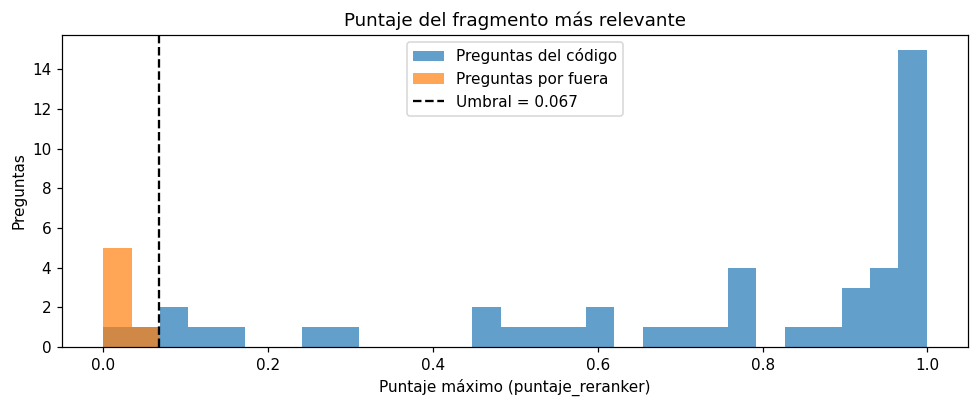

In [30]:
columna_puntaje = 'puntaje_reranker' if RERANKER_FINAL else 'similitud'
maximos = (candidatos[(candidatos.embedding == EMB_FINAL) & (candidatos.estrategia == ESTRATEGIA_FINAL)]
           .groupby('id')[columna_puntaje].max().rename('puntaje_max').reset_index()
           .merge(preguntas[['id', 'en_dominio']], on='id'))

candidatos_umbral = np.unique(maximos.puntaje_max)
evaluacion_umbral = pd.DataFrame({
    'umbral': candidatos_umbral,
    'aceptadas_en_dominio': [(maximos.loc[maximos.en_dominio, 'puntaje_max'] >= u).mean() for u in candidatos_umbral],
    'rechazadas_fuera': [(maximos.loc[~maximos.en_dominio, 'puntaje_max'] < u).mean() for u in candidatos_umbral]})
evaluacion_umbral['exactitud_balanceada'] = evaluacion_umbral[['aceptadas_en_dominio', 'rechazadas_fuera']].mean(axis=1)
UMBRAL = float(evaluacion_umbral.sort_values(['exactitud_balanceada', 'umbral'], ascending=[False, True]).umbral.iloc[0])
print(f'Umbral elegido sobre {columna_puntaje}: {UMBRAL:.4f}')
print(evaluacion_umbral.loc[evaluacion_umbral.umbral == UMBRAL].round(3).to_string(index=False))

fig, eje = plt.subplots(figsize=(9, 3.8))
bins = np.linspace(maximos.puntaje_max.min(), maximos.puntaje_max.max(), 30)
eje.hist(maximos.loc[maximos.en_dominio, 'puntaje_max'], bins=bins, alpha=0.7, label='Preguntas del código')
eje.hist(maximos.loc[~maximos.en_dominio, 'puntaje_max'], bins=bins, alpha=0.7, label='Preguntas por fuera')
eje.axvline(UMBRAL, color='black', linestyle='--', label=f'Umbral = {UMBRAL:.3f}')
eje.set_xlabel(f'Puntaje máximo ({columna_puntaje})')
eje.set_ylabel('Preguntas')
eje.set_title('Puntaje del fragmento más relevante')
eje.legend()
plt.tight_layout()
plt.show()

In [31]:
final = respuestas_llm[respuestas_llm.modelo == LLM_FINAL].merge(maximos[['id', 'puntaje_max']], on='id',
                                                                  suffixes=('_ctx', ''))
final['bloqueada_por_umbral'] = final.puntaje_max < UMBRAL
final['abstencion_final'] = final.bloqueada_por_umbral | final.abstencion
final['cita_correcta_final'] = final.cita_correcta & ~final.bloqueada_por_umbral

efecto_umbral = pd.DataFrame({
    'sin umbral': [final.loc[final.en_dominio, 'cita_correcta'].mean(),
                   final.loc[~final.en_dominio, 'abstencion'].mean(),
                   final.loc[final.en_dominio, 'abstencion'].mean()],
    'con umbral': [final.loc[final.en_dominio, 'cita_correcta_final'].mean(),
                   final.loc[~final.en_dominio, 'abstencion_final'].mean(),
                   final.loc[final.en_dominio, 'abstencion_final'].mean()]},
    index=['citas correctas', 'abstención fuera de dominio', 'abstención indebida']).round(3)
print(f'Modelo: {LLM_FINAL}')
display(efecto_umbral)
print('Preguntas del código bloqueadas por el umbral:')
final.loc[final.en_dominio & final.bloqueada_por_umbral, ['id', 'puntaje_max']].merge(
    preguntas[['id', 'pregunta']], on='id')

Modelo: gemma3:4b


,sin umbral,con umbral
citas correctas,0.891,0.870
abstención fuera de dominio,0.833,1.000
abstención indebida,0.043,0.065


Preguntas del código bloqueadas por el umbral:


,id,puntaje_max,pregunta
0,39,0.015748,¿Qué me pasa si me cogen manejando borracho?


In [32]:
recuperador.umbral = UMBRAL
llm_final = crear_llm(LLM_FINAL)
cadena_qa = crear_cadena_qa(llm_final, recuperador)
for pregunta in ['¿Cómo se prepara un sancocho de gallina?', '¿Puedo girar a la derecha cuando el semáforo está en rojo?']:
    print('•', pregunta)
    print(formatear_respuesta(cadena_qa.invoke({'input': pregunta})), '\n')

• ¿Cómo se prepara un sancocho de gallina?
No encontré esa información en el Código Nacional de Tránsito. 

• ¿Puedo girar a la derecha cuando el semáforo está en rojo?
Sí, puede girar a la derecha cuando el semáforo está en rojo, respetando la prelación del peatón. (Art. 118)

**Referencias (Ley 769 de 2002):**
- [1] Art. 118 – SIMBOLOGÍA DE LAS SEÑALES LUMINOSAS
- [2] Art. 70 – PRELACIÓN EN INTERSECCIONES O GIROS 



### Lo que encontramos con el umbral

**H5 (umbral de abstención): se cumple, con una advertencia.** El umbral que maximiza la exactitud balanceada es 0,067 sobre el puntaje del cross-encoder. Con él se aceptan 45 de las 46 preguntas del código y se rechazan las 6 de fuera, para una exactitud balanceada de 0,989. Sobre las respuestas de `gemma3:4b`, el efecto es este:

| Medida | Sin umbral | Con umbral |
|---|---|---|
| Abstención fuera de dominio | 0,833 | 1,0 |
| Citas correctas | 0,891 | 0,870 |
| Abstención indebida | 0,043 | 0,065 |

Las dos últimas cambian por una sola pregunta.

La pregunta que se pierde es "¿Qué me pasa si me cogen manejando borracho?", con un puntaje de 0,016. Es una de las cinco preguntas que no comparten ninguna palabra con sus artículos correctos (26 y 152): la gente dice "borracho" y la ley habla de "embriaguez" y "alcoholemia". Ese 0,016 es el puntaje del mejor de sus 20 candidatos, así que el cross-encoder no encontró ningún fragmento que relacionara claramente con la pregunta.

La advertencia se ve en el histograma: el margen es muy estrecho. Las preguntas externas quedan todas por debajo de 0,07, y el umbral coincide con el puntaje de la pregunta del código con menor puntaje entre las aceptadas. Además hay varias preguntas del código entre 0,07 y 0,3, muy cerca del corte, y calibramos y evaluamos el umbral con las mismas seis preguntas externas. Con otras preguntas coloquiales es probable que aparezcan más casos como el de "borracho".

En la prueba de la celda anterior, la pregunta del sancocho se bloquea sin llamar al modelo. La del giro a la derecha con el semáforo en rojo pasa el umbral y se responde con el artículo 118.

---
## 13. Conversación con memoria

Hasta aquí cada pregunta es independiente. En una conversación real la gente pregunta cosas como "¿y en carretera?", que solo se entiende con lo que se dijo antes. Usamos `create_history_aware_retriever`: antes de buscar, el modelo reescribe la última pregunta para que se entienda sin el historial, y con esa pregunta reescrita se hace la recuperación. La respuesta final sí recibe el historial completo.


In [33]:
from langchain_classic.chains import create_history_aware_retriever
from langchain_core.messages import AIMessage, HumanMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate

PROMPT_REFORMULAR = ChatPromptTemplate.from_messages([
    ('system', 'Dada la conversación y la última pregunta del usuario, reescribe esa pregunta para que se entienda '
               'sin la conversación. No la respondas: devuelve solo la pregunta reescrita.'),
    ('placeholder', '{chat_history}'),
    ('human', '{input}'),
])

PROMPT_CONVERSACION = ChatPromptTemplate.from_messages([
    ('system', INSTRUCCIONES + '\n\nContexto:\n{context}'),
    ('placeholder', '{chat_history}'),
    ('human', '{input}'),
])

recuperador_con_historial = create_history_aware_retriever(llm_final, recuperador, PROMPT_REFORMULAR)
cadena_conversacional = create_retrieval_chain(
    recuperador_con_historial, con_atajo_de_abstencion(create_stuff_documents_chain(llm_final, PROMPT_CONVERSACION)))
reformulador = PROMPT_REFORMULAR | llm_final | StrOutputParser()

historial = []
for pregunta in ['¿Cuál es la velocidad máxima permitida dentro de la ciudad?', '¿Y en una carretera nacional?']:
    if historial:
        print('Pregunta reescrita para la búsqueda:', reformulador.invoke({'input': pregunta, 'chat_history': historial}))
    salida = cadena_conversacional.invoke({'input': pregunta, 'chat_history': historial})
    historial += [HumanMessage(content=pregunta), AIMessage(content=salida['answer'])]
    print(f'• {pregunta}\n{formatear_respuesta(salida)}\n')

• ¿Cuál es la velocidad máxima permitida dentro de la ciudad?
En las vías urbanas, la velocidad máxima permitida es de cincuenta (50) kilómetros por hora. (Art. 106)

**Referencias (Ley 769 de 2002):**
- [1] Art. 106 – LÍMITES DE VELOCIDAD EN VÍAS URBANAS Y CARRETERAS MUNICIPALES
- [2] Art. 107 – LÍMITES DE VELOCIDAD EN CARRETERAS NACIONALES Y DEPARTAMENTALES

Pregunta reescrita para la búsqueda: ¿Cuál es la velocidad máxima permitida en una carretera nacional?
• ¿Y en una carretera nacional?
En las carreteras nacionales y departamentales, la velocidad máxima permitida es de noventa (90) kilómetros por hora. (Art. 107)

**Referencias (Ley 769 de 2002):**
- [1] Art. 107 – LÍMITES DE VELOCIDAD EN CARRETERAS NACIONALES Y DEPARTAMENTALES
- [2] Art. 106 – LÍMITES DE VELOCIDAD EN VÍAS URBANAS Y CARRETERAS MUNICIPALES



**Lo que observamos.** La conversación de prueba tiene dos turnos:

1. "¿Cuál es la velocidad máxima permitida dentro de la ciudad?" recupera el artículo 106, y la respuesta es 50 km/h.
2. "¿Y en una carretera nacional?" no dice de qué se está hablando. El modelo la reescribe como "¿Cuál es la velocidad máxima permitida en una carretera nacional?", el recuperador trae primero el artículo 107 y la respuesta es 90 km/h.

Sin la reescritura, el recuperador solo tendría "carretera nacional" para buscar y no sabría que la pregunta es sobre velocidad. El costo es una llamada adicional al modelo en cada turno después del primero.

---
## 14. Chatbot con Gradio

La interfaz tiene dos columnas. A la izquierda está la conversación, y cada respuesta termina con sus referencias. A la derecha, un panel muestra los artículos que se recuperaron para la última pregunta, con su puntaje de relevancia y un extracto del texto, para que quien use el asistente pueda comprobar de dónde sale la respuesta.

Manejamos dos historiales por separado: `lc_history`, con los mensajes de LangChain que necesita la cadena, y el historial de Gradio, que solo sirve para pintar el chat. En Colab, `share=True` genera un enlace público temporal para abrir la interfaz desde el navegador.

In [38]:
import gradio as gr

lc_history = []


def panel_fuentes(contexto):
    if not contexto:
        return ('### Artículos consultados\n\n_Ningún artículo superó el umbral de relevancia, así que el asistente '
                'no respondió con información del código._')
    lineas = ['### Artículos consultados']
    for i, doc in enumerate(contexto, 1):
        m = doc.metadata
        extracto = doc.page_content.split('\n', 1)[-1][:350].replace('\n', ' ')
        lineas.append(f"**{i}. Art. {m['articulo']}{' – ' + m['nombre'] if m['nombre'] else ''}** · "
                      f"relevancia {m['puntaje']:.3f}\n\n> {extracto}…")
    lineas.append(f'\nFuente: [Ley 769 de 2002 – Función Pública]({FUENTE_URL})')
    return '\n\n'.join(lineas)


def responder(pregunta, chat_history):
    chat_history = chat_history or []
    if not pregunta.strip():
        return '', chat_history, gr.update()
    salida = cadena_conversacional.invoke({'input': pregunta, 'chat_history': lc_history})
    lc_history.extend([HumanMessage(content=pregunta), AIMessage(content=salida['answer'])])
    chat_history = chat_history + [{'role': 'user', 'content': pregunta},
                                   {'role': 'assistant', 'content': formatear_respuesta(salida)}]
    return '', chat_history, panel_fuentes(salida['context'])


def reiniciar():
    lc_history.clear()
    return '', [], ''


with gr.Blocks() as demo:
    gr.Markdown('# Asistente del Código Nacional de Tránsito\n'
                'Responde con base en la Ley 769 de 2002 según la compilación de Función Pública '
                f'(texto descargado el {ley.fecha_descarga.iloc[0]}). Es una herramienta de orientación y '
                '**no reemplaza una asesoría legal**.')
    with gr.Row():
        with gr.Column(scale=3):
            chatbot = gr.Chatbot(label='Conversación', height=480)
            msg = gr.Textbox(label='¿Qué quieres saber sobre las normas de tránsito?',
                             placeholder='Escribe tu pregunta aquí y presiona Enter.')
            with gr.Row():
                enviar = gr.Button('Enviar', variant='primary')
                limpiar = gr.Button('Limpiar')
        with gr.Column(scale=2):
            fuentes = gr.Markdown()

    msg.submit(responder, [msg, chatbot], [msg, chatbot, fuentes])
    enviar.click(responder, [msg, chatbot], [msg, chatbot, fuentes])
    limpiar.click(reiniciar, None, [msg, chatbot, fuentes], queue=False)

demo.launch(share=IN_COLAB, inline=True, debug=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://1f670d2f1c4dbcbf38.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [39]:
demo.close()

Closing server running on port: 7861


### Video de la demostración

Grabamos una demostración corta del chatbot en funcionamiento, con la interfaz de Gradio y el panel de artículos consultados.

[![Video de la demostración del asistente](https://img.youtube.com/vi/sLOot9PUMx0/hqdefault.jpg)](https://www.youtube.com/watch?v=sLOot9PUMx0)


---
## 15. Resultados y conclusiones

### Respuesta a la pregunta de investigación

La mejor combinación que encontramos para recuperar artículos del Código de Tránsito es:

- fragmentar siguiendo la estructura de la ley;
- buscar con `BAAI/bge-m3`;
- reordenar los 20 primeros candidatos con `BAAI/bge-reranker-v2-m3`;
- pasarle al generador los 3 mejores fragmentos.

Con esa configuración, el fragmento que contiene la respuesta está entre los 3 recuperados en el 95,7 % de las preguntas y entre los 5 primeros en todas. Las dos variantes de e5-large quedaron empatadas con bge-m3 usando la misma fragmentación y el mismo re-ranking, así que el modelo de embeddings pesa mucho menos que esas dos decisiones. Como generador, `gemma3:4b` aprovecha mejor el contexto: cita un artículo correcto en el 89,1 % de las preguntas del código y ninguna de sus citas se refiere a un artículo que no estuviera en el contexto.

### Hipótesis

| Hipótesis | Resultado | Evidencia principal |
|---|---|---|
| H1. La fragmentación estructural recupera mejor | Se cumple | Evidencia@5 promedio de 0,994 con re-ranking, frente a 0,952 del artículo completo y 0,913 de la ventana |
| H2. Los prefijos de E5 mejoran la recuperación | No se cumple | Sin re-ranking, e5-large sin prefijos iguala o supera a la versión con prefijos; con re-ranking quedan iguales |
| H3. El re-ranking mejora sobre todo el MRR | Se cumple | La MRR@10 sube en las tres estrategias; con estructural pasa de 0,879 a 0,943 |
| H4. `gemma3:4b` cita mejor, pero es más lento | Se cumple | 0,891 de citas correctas frente a 0,717, con 0,4 s más por respuesta |
| H5. El umbral rechaza lo externo sin perder mucho | Se cumple, con reservas | Rechaza las 6 preguntas externas y pierde 1 de las 46 del código, pero con un margen muy estrecho |

### El asistente final

Con el umbral activo, `gemma3:4b`:

- cita un artículo correcto en el 87,0 % de las preguntas del código;
- se abstiene en todas las preguntas externas;
- se abstiene sin razón en 3 de las 46 preguntas del código (6,5 %).

En la comparación respondió en 3,0 s en promedio sobre la T4. Cada respuesta muestra las referencias y los fragmentos consultados con su puntaje, así que quien lo use puede ir directamente al texto de la ley y comprobarlo. La conversación con memoria resuelve preguntas de seguimiento como "¿y en una carretera nacional?" porque las reescribe antes de buscar.

### Lo que aprendimos

- **Encontrar el artículo no es lo mismo que encontrar la respuesta.** Si solo hubiéramos medido Recall@k, la ventana deslizante habría parecido casi tan buena como la fragmentación estructural (0,967 frente a 0,984 con re-ranking). La Evidencia@k mostró que la ventana separa el literal de una infracción del párrafo que dice cuánto vale la multa (0,913 frente a 0,994).
- **Sin contexto, los modelos inventan con seguridad.** `gemma3:4b` citó artículos que no existen y valores que no están en la ley. Con RAG, el mismo modelo no citó ningún artículo por fuera de los fragmentos recuperados.
- **Tener la evidencia no garantiza que el modelo la use.** Con el literal D.4 y su multa en el contexto, `llama3.2:3b` dijo que no encontró la información sobre el semáforo en rojo. `gemma3:4b` respondió bien, pero sin escribir la cita.
- **El umbral es una buena segunda barrera, pero depende del vocabulario.** Bloqueó todas las preguntas externas y también la de "borracho", porque ninguno de sus fragmentos candidatos obtuvo un puntaje alto: la ley no usa esa palabra, sino "embriaguez".

### Limitaciones

- **El set de evaluación es pequeño y lo escribimos nosotros.** Son 46 preguntas del código y 6 externas, y cada pregunta del código pesa 2,2 puntos, por eso varias configuraciones terminan empatadas.
- **Las métricas de citas miran el número del artículo, no el contenido.** La respuesta del semáforo tenía el contenido correcto sin la cita, y el caso contrario, una cita correcta con un dato equivocado, no lo medimos. La Evidencia@k, por su parte, busca la frase literal.
- **El umbral se calibró y se evaluó con las mismas seis preguntas externas** y queda muy cerca de algunas preguntas válidas.
- **El asistente depende de la compilación de Función Pública.** Si esa compilación tarda en incorporar una reforma, el asistente responde con la redacción que tenga publicada. Además, da las multas en SMLDV, sin convertirlas a pesos.
- **Solo cubrimos la Ley 769 de 2002.** Quedan por fuera los decretos reglamentarios, las resoluciones y las normas locales.

### Trabajo futuro

- Ampliar el set con preguntas escritas por otras personas y con más preguntas externas parecidas al tema (plataformas de transporte, pico y placa, impuestos), para calibrar el umbral con datos separados de los de evaluación.
- Probar una búsqueda híbrida con BM25 o una expansión de la consulta con sinónimos coloquiales ("borracho" → "embriaguez", "pase" → "licencia de conducción"), pensando en las preguntas que no comparten palabras con la ley.
- Evaluar el contenido de las respuestas y no solo la cita, por ejemplo comprobando que los números de la respuesta aparezcan en los fragmentos recuperados.
- Convertir los SMLDV a pesos con el salario mínimo vigente y comparar cada artículo con las normas que lo reformaron, para detectar si la compilación está desactualizada.